# PI3 R

In [4]:
csv = "https://raw.githubusercontent.com/PedroF-Santos/Teoria-do-aprendizado-estatistico-01-26---Julia-Pedro-e-Thabata/main/Dados_baixada_att.csv"

### Carregar bibliotecas necessárias

In [5]:
install.packages("corrplot")
install.packages("lmtest")
install.packages("FNN")
install.packages("randomForest")
install.packages("dbscan")

library(dbscan)
library(FNN)
library(ggplot2)
library(corrplot)
library(lmtest)
library(randomForest)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dbscan’


The following object is masked from ‘package:stats’:

    as.dendrogram


corrplot 0.95 loaded

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin




### Leitura do CSV

In [6]:
df <- read.csv(csv, fileEncoding = "latin1", sep = ";", dec = ",")

In [7]:
head(df, n = 1)

,Municipio,CodPonto,SEQID,SistHidrico,Coleta_Data,Cloreto.Total,Condutividade,Escherichia.coli..,Fósforo.Total,Oxigênio.Dissolvido,⋯,Sólido.Total,Temperatura.da.Água,Turbidez,pH,X,X.1,X.2,X.3,X.4,X.5
,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,⋯,<int>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,CUBATAO,CFUG02900,208,Canal de Fuga II da UHE Henry Borden - CFUG,14/01/2016,12.5,151,12,0.007,7.7,⋯,186,25.9,7.73,6.64,NA,NA,NA,NA,NA,NA


### Vetor de colunas

In [8]:
#Variaveis
Cloreto_Total <- df$Cloreto.Total
Solido_Dissolvido_Total <- df$Sólido.Dissolvido.Total
Solido_Total <- df$Sólido.Total
Condutividade <- df$Condutividade
Temperatura_da_agua <- df$Temperatura.da.Água
Ph <-  df$pH
Turbidez <- df$Turbidez
Oxigenio_dissolvido <- df$Oxigênio.Dissolvido
Escherichia_coli <- df$Escherichia.coli..
Fosforo_total <- df$Fósforo.Total



colunas <- c(
  "Cloreto.Total",
  "Condutividade",
  "Escherichia.coli..",
  "Fósforo.Total",
  "Oxigênio.Dissolvido",
  "Sólido.Dissolvido.Total",
  "Sólido.Total",
  "Temperatura.da.Água",
  "Turbidez",
  "pH"
)

# Converter colunas para numérico
df[colunas] <- lapply(df[colunas], function(x) as.numeric(as.character(x)))


### Loop para histogramas

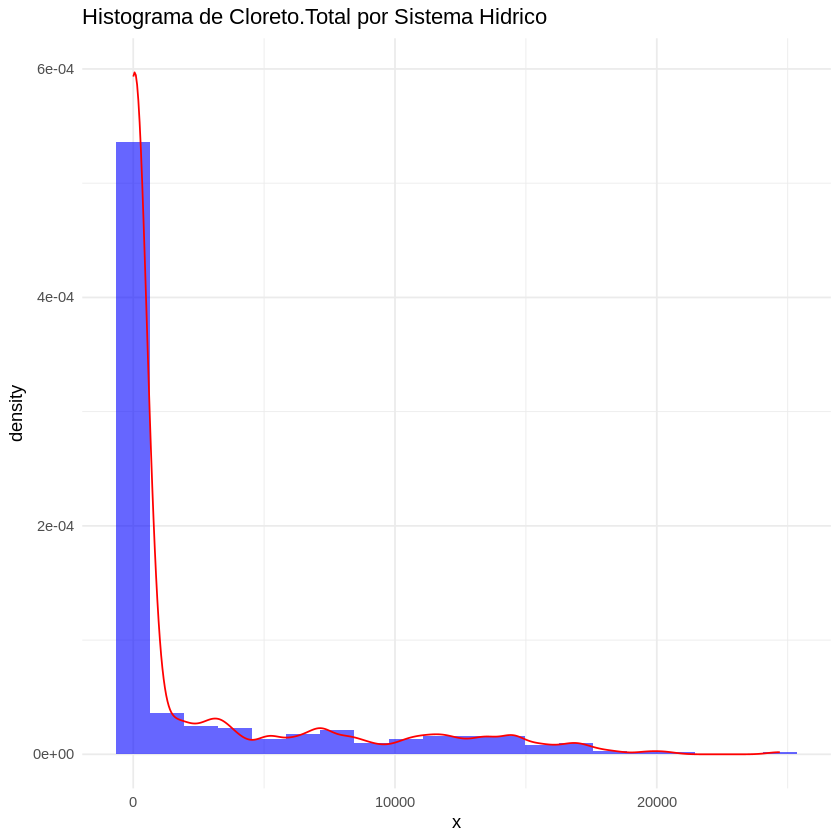

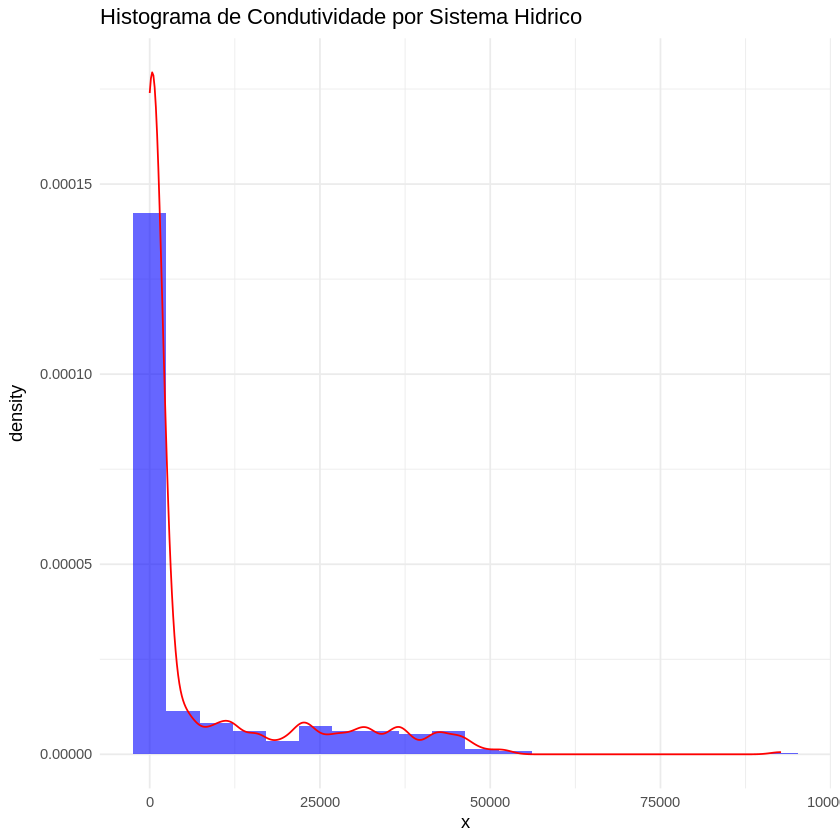

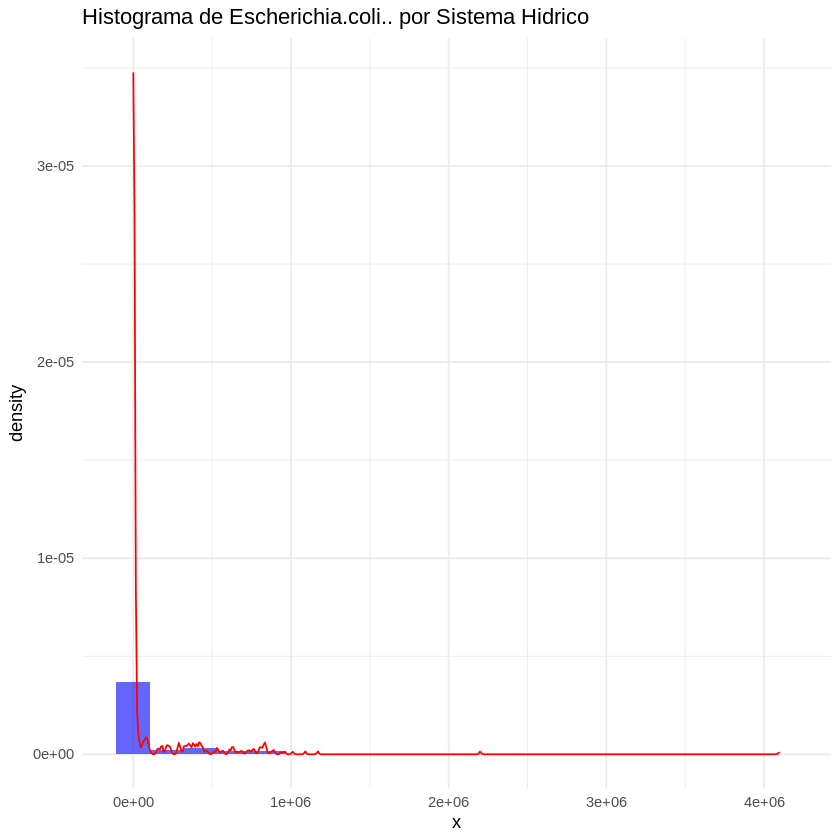

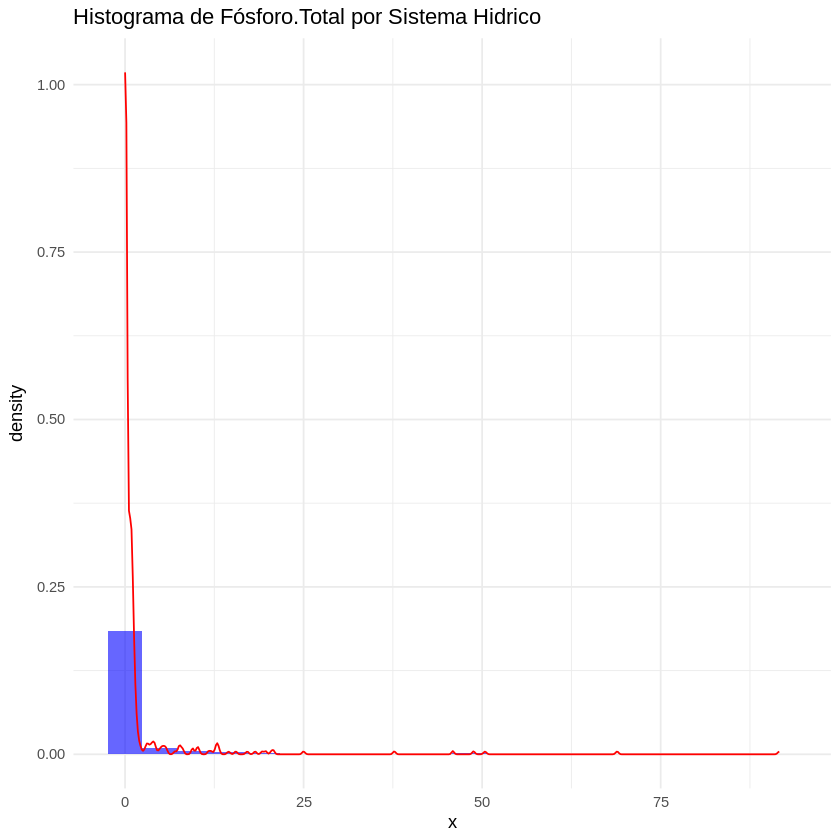

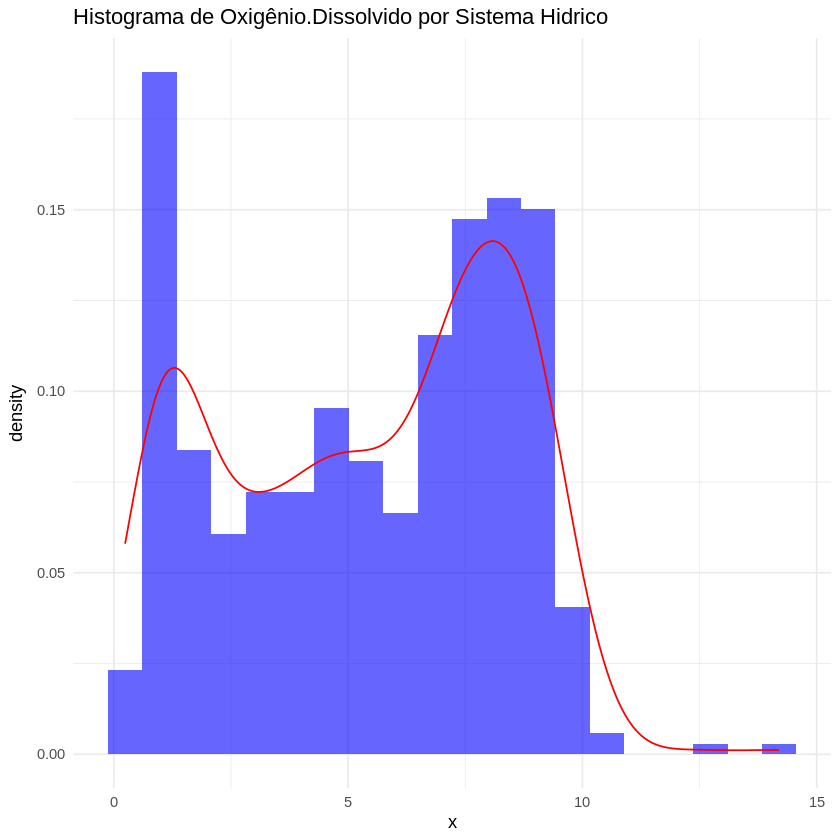

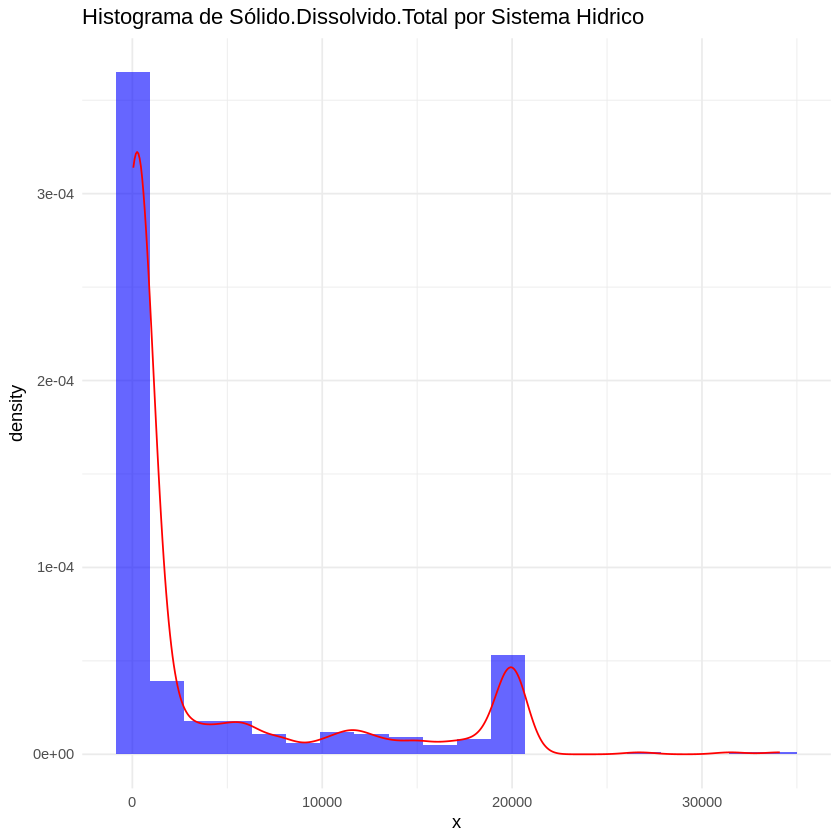

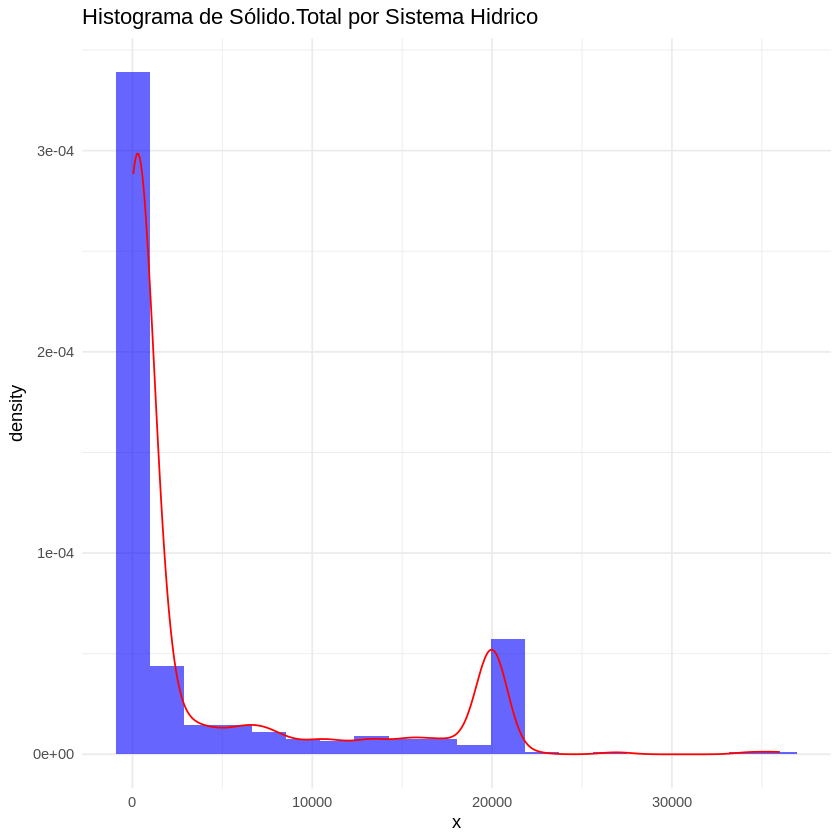

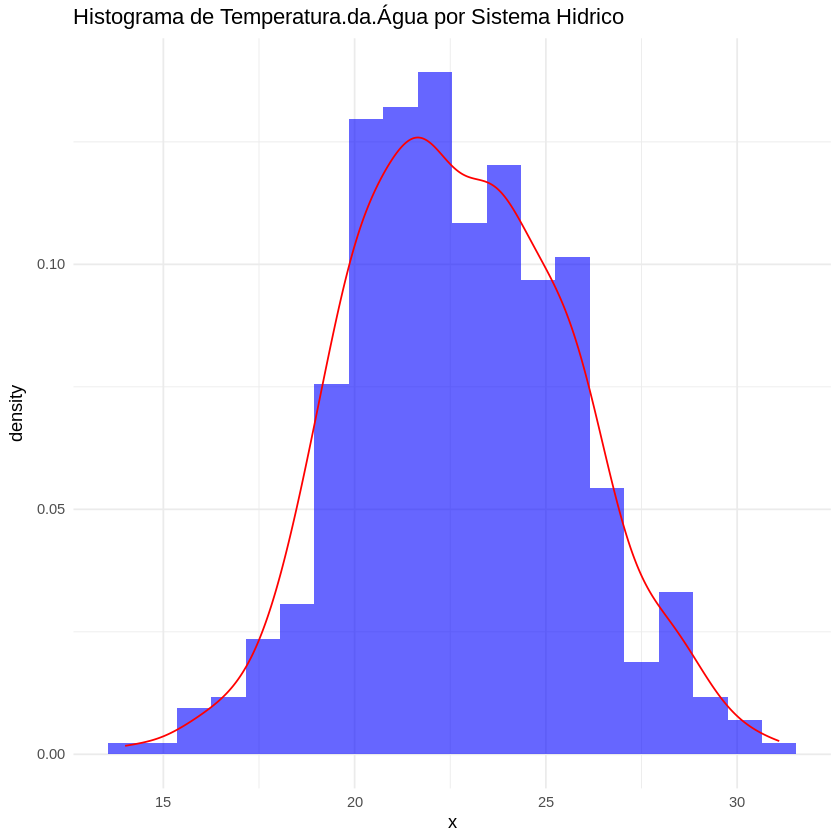

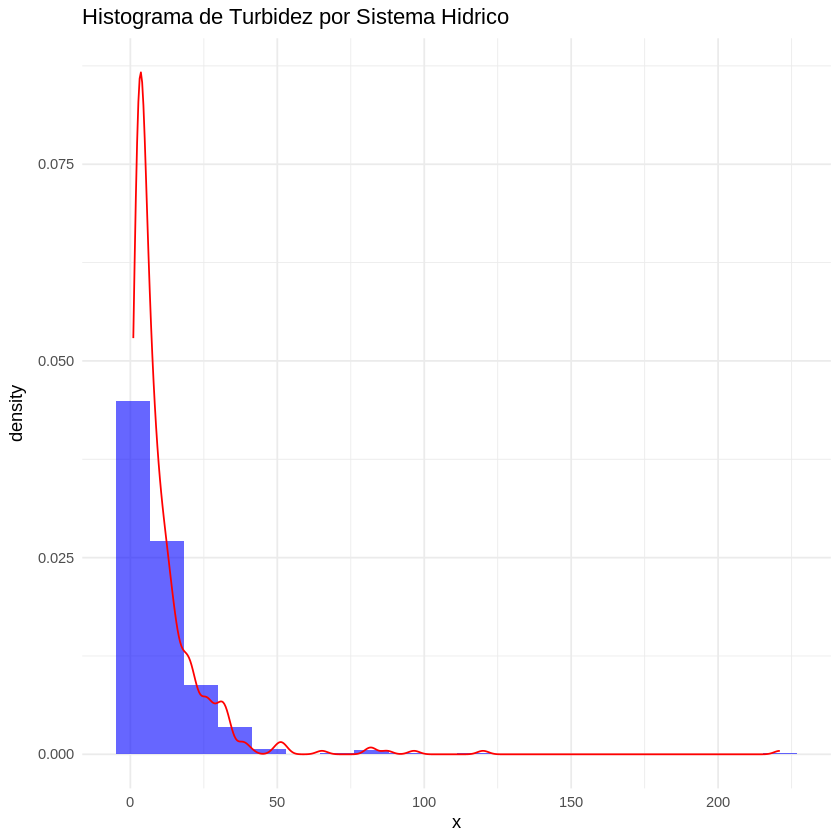

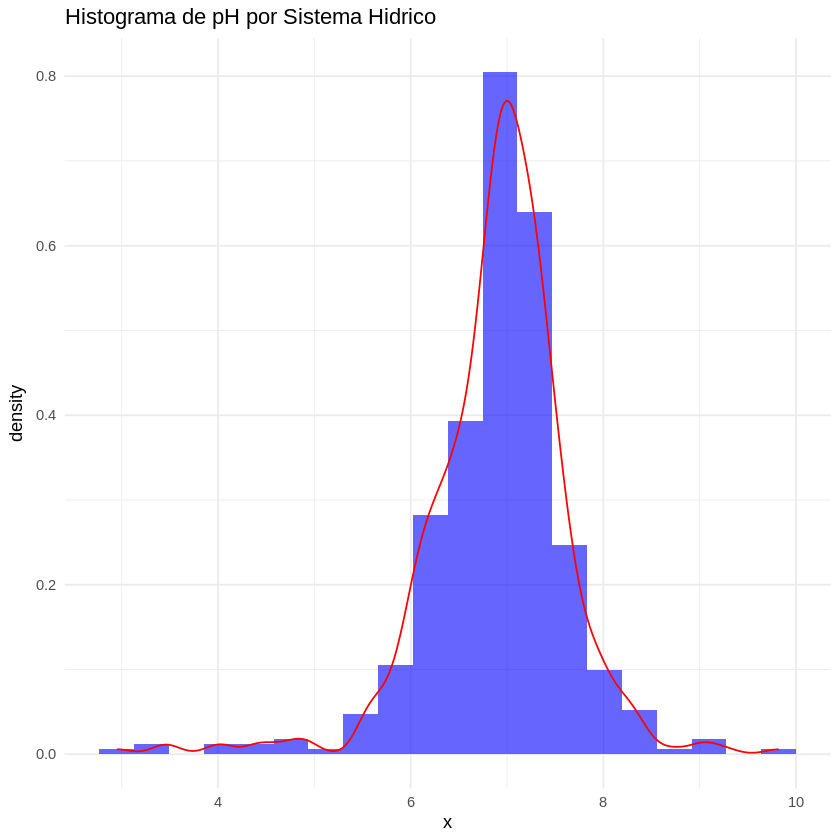

In [9]:
#for (col in colunas) {

  #p <- ggplot(df, aes_string(x = col)) +
    #geom_histogram(aes(y = ..density..), bins = 20, fill = "blue", alpha = 0.6) +
    #geom_density(color = "red") +
    #ggtitle(paste("Histograma de", col, "por Sistema Hidrico")) +
    #theme_minimal()

  #print(p)
#}

for (col in colunas) {

  dados <- df[[col]]
  dados <- dados[is.finite(dados)]  # remove NA, NaN, Inf

  p <- ggplot(data.frame(x = dados), aes(x = x)) +
    geom_histogram(aes(y = after_stat(density)), bins = 20, fill = "blue", alpha = 0.6) +
    geom_density(color = "red") +
    ggtitle(paste("Histograma de", col, "por Sistema Hidrico")) +
    theme_minimal()

  print(p)
}

### Variáveis normais

In [10]:
Normal <- c(
  "Temperatura.da.Água",
  "pH"
)

for (norm in Normal) {
  dados <- df[[norm]]

  mu <- mean(dados, na.rm = TRUE)
  sigma <- sd(dados, na.rm = TRUE)

  cat(paste("Média", norm, ":", mu, "\n"))
  cat(paste("Desvio padrão", norm, ":", sigma, "\n"))
}



Média Temperatura.da.Água : 22.7475583864119 
Desvio padrão Temperatura.da.Água : 2.88535358360719 
Média pH : 6.90774946921444 
Desvio padrão pH : 0.733827062990578 


### Variaveis exponenciais

In [11]:
Exponencial = c(
  "Cloreto.Total",
  "Condutividade",
  "Escherichia.coli..",
  "Fósforo.Total",
  "Sólido.Dissolvido.Total",
  "Sólido.Total",
  "Turbidez"
)

for (exp in Exponencial) {
  dados <- df[[exp]]

  mu <- mean(dados, na.rm = TRUE)
  sigma <- sd(dados, na.rm = TRUE)

  cat(paste("Média", exp, ":", mu, "\n"))
  cat(paste("Desvio padrão", exp, ":", sigma, "\n"))
}





#for (col in Exponencial) {

  #dados <- df[[col]]
  #dados <- dados[is.finite(dados) & dados > 0]

  #lambda <- 1 / mean(dados, na.rm = TRUE)

  #cat(paste("Lambda (", col, "):", lambda, "\n"))


  #dados_df <- data.frame(x = dados)

 # p <- ggplot(dados_df, aes(x = x)) +
  #  geom_histogram(aes(y = after_stat(density)), bins = 20, fill = "blue", alpha = 0.6) +
   # stat_function(fun = dexp, args = list(rate = lambda), color = "red", linewidth = 1) +
    #ggtitle(paste("Distribuição Exponencial -", col)) +
    #theme_minimal()

  #print(p)
#}




Média Cloreto.Total : 2465.14658174098 
Desvio padrão Cloreto.Total : 4709.77828891624 
Média Condutividade : 7475.14959660297 
Desvio padrão Condutividade : 13535.9693046452 
Média Escherichia.coli.. : 118401.492569002 
Desvio padrão Escherichia.coli.. : 309261.142533874 
Média Fósforo.Total : 2.00037191489362 
Desvio padrão Fósforo.Total : 7.37127760592146 
Média Sólido.Dissolvido.Total : 3991.54777070064 
Desvio padrão Sólido.Dissolvido.Total : 6929.50817705734 
Média Sólido.Total : 4286.57537154989 
Desvio padrão Sólido.Total : 7262.21117740764 
Média Turbidez : 10.9943949044586 
Desvio padrão Turbidez : 16.0724063393549 


### Matriz de correlação

In [12]:
# Selecionar colunas
cols <- c(
  "Cloreto.Total",
  "Condutividade",
  "Escherichia.coli..",
  "Fósforo.Total",
  "Sólido.Dissolvido.Total",
  "Sólido.Total",
  "Turbidez"
)

# Filtrar apenas essas colunas
df_corr <- df[cols]

# Converter para numérico (garantia)
df_corr <- as.data.frame(lapply(df_corr, function(x) as.numeric(as.character(x))))

# Remover linhas com NA
df_corr <- na.omit(df_corr)

# Matriz de correlação de Pearson
cor_matrix <- cor(df_corr, method = "pearson")

# Mostrar matriz no console
print(cor_matrix)





                        Cloreto.Total Condutividade Escherichia.coli..
Cloreto.Total              1.00000000    0.90624059        -0.11724082
Condutividade              0.90624059    1.00000000        -0.10650468
Escherichia.coli..        -0.11724082   -0.10650468         1.00000000
Fósforo.Total             -0.11842539   -0.10680980        -0.05060801
Sólido.Dissolvido.Total    0.95541623    0.89958189        -0.10682629
Sólido.Total               0.94337042    0.89433534        -0.10432251
Turbidez                  -0.06778737   -0.04146437         0.34887732
                        Fósforo.Total Sólido.Dissolvido.Total Sólido.Total
Cloreto.Total             -0.11842539              0.95541623   0.94337042
Condutividade             -0.10680980              0.89958189   0.89433534
Escherichia.coli..        -0.05060801             -0.10682629  -0.10432251
Fósforo.Total              1.00000000             -0.09914706  -0.09918108
Sólido.Dissolvido.Total   -0.09914706              1.0000

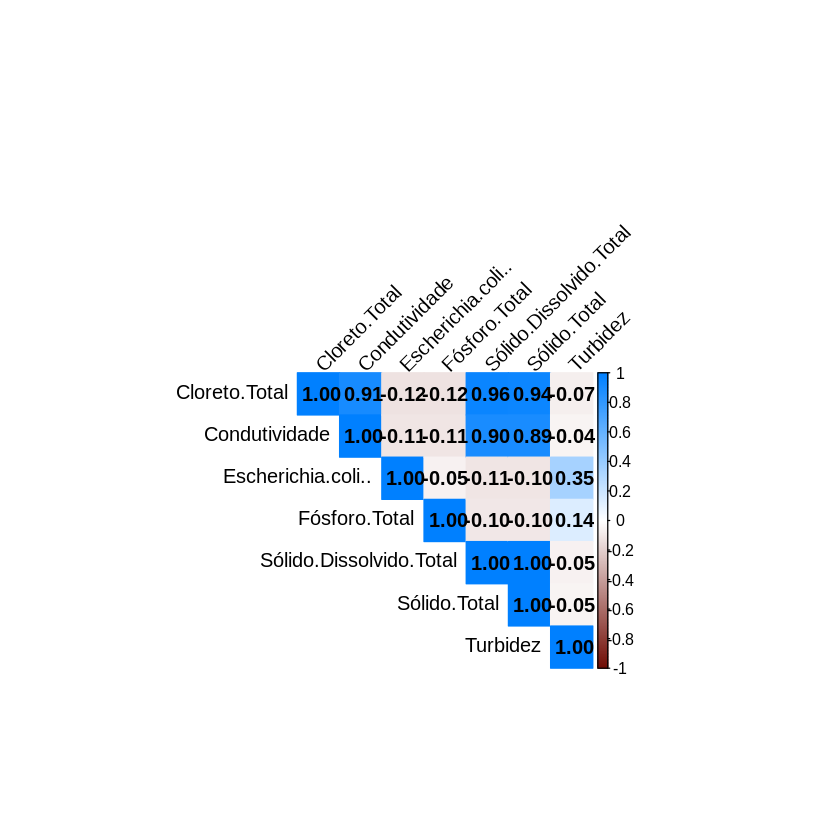

In [13]:
# Plotar heatmap
#ng("heatmap.png", width = 600, height = 450)

col = colorRampPalette(c("#0E4D92","WHITE","#710C04"))
corrplot(cor_matrix,
         method = "color",
         type = "upper",
         tl.col = "black",
         col = colorRampPalette(c("#710C04","white","#0080FF"))(200),
         tl.srt = 45,
         addCoef.col = "black",
         number.cex = 1)
#dev.off()

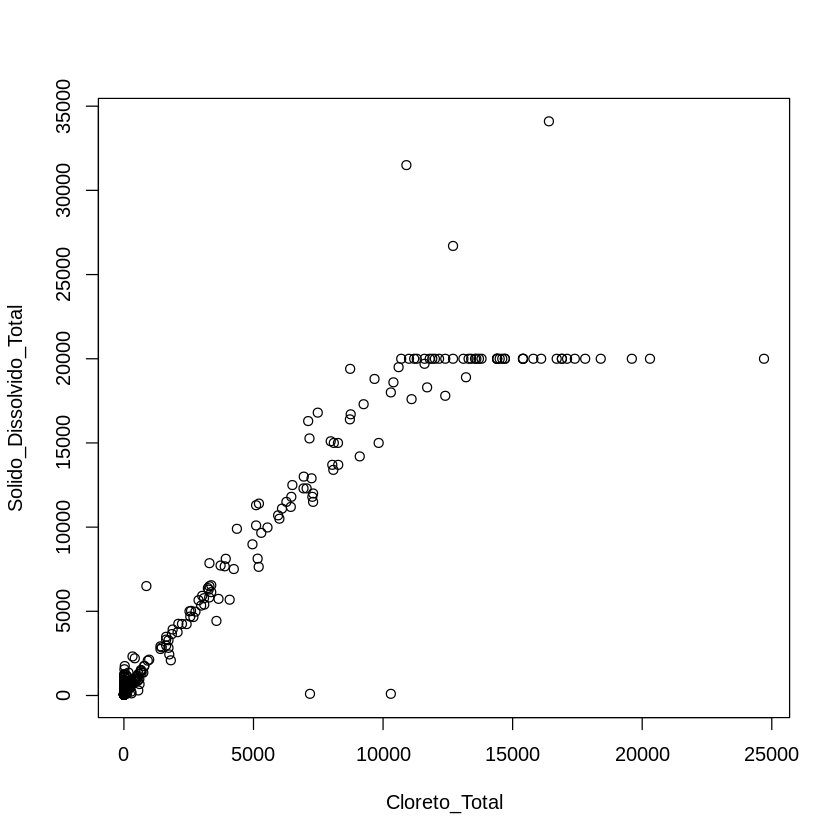

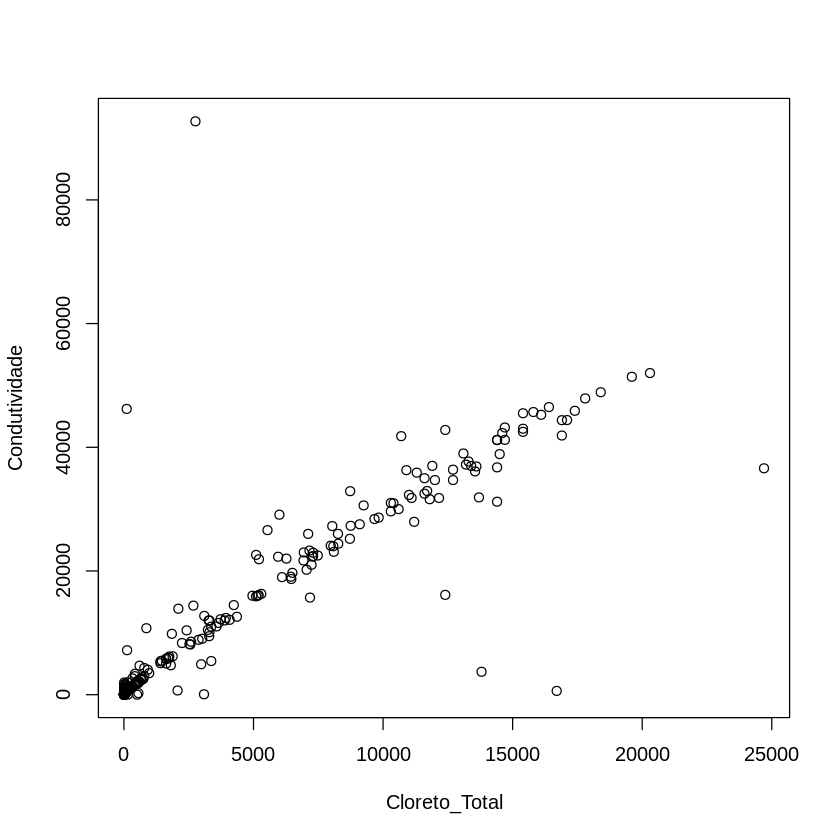

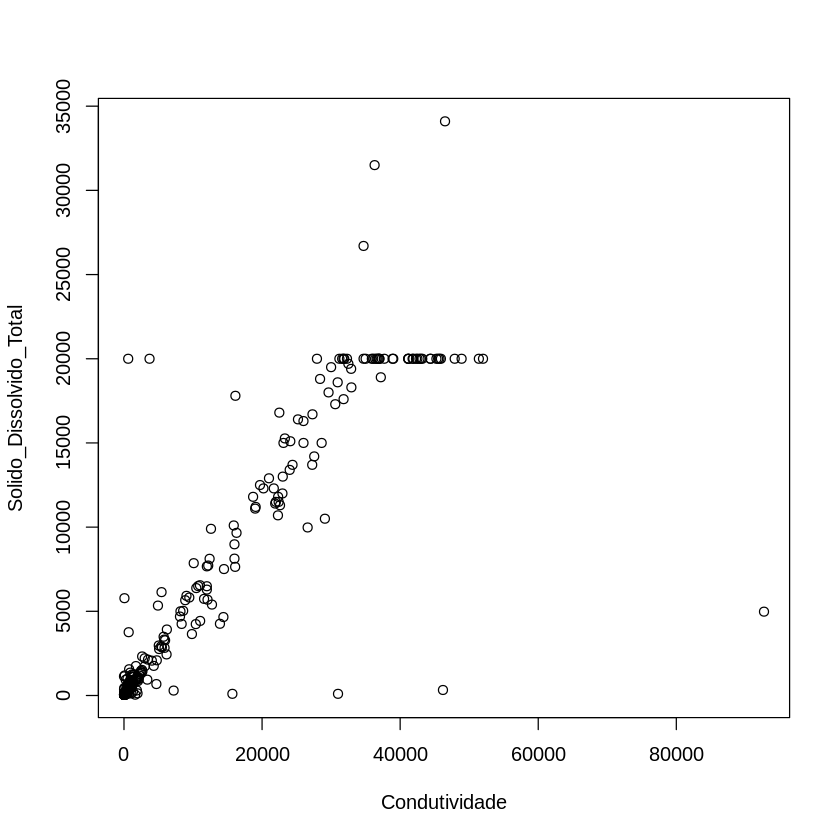

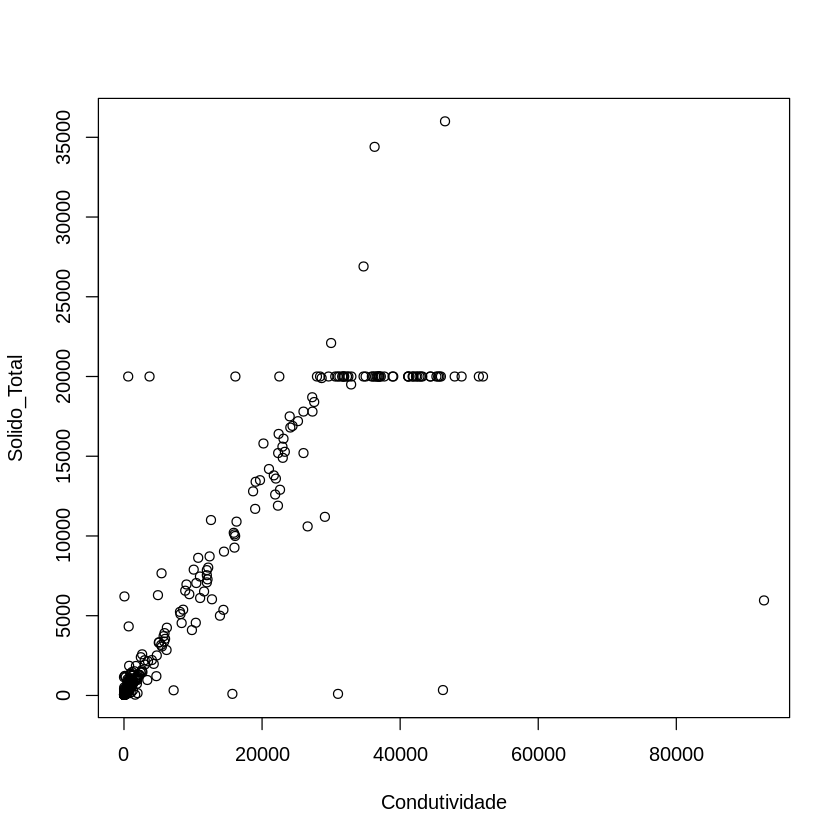

In [14]:
#cor.test(
  #Cloreto_Total,
  #Solido_Dissolvido_Total
#)

plot(
  Cloreto_Total,
  Solido_Dissolvido_Total
)

#cor.test(
  #Cloreto_Total,
  #Condutividade
#)
#png("cloreto total x condutividade.png", width = 600, height = 450)
plot(
  Cloreto_Total,
  Condutividade
)
#dev.off()

#cor.test(
  #Condutividade,
  #Solido_Dissolvido_Total
#)
#png("condutividade x solido dissolvido.png", width = 600, height = 450)
plot(
  Condutividade,
  Solido_Dissolvido_Total
)
#dev.off()

#cor.test(
  #Condutividade,
  #Solido_Total
#)
#png("condutividade x solido total.png", width = 600, height = 450)
plot(
  Condutividade,
  Solido_Total
)
#dev.off()

### Criar uma função dado uma preditora e uma target


Call:
lm(formula = Condutividade ~ Cloreto_Total, data = df)

Residuals:
   Min     1Q Median     3Q    Max 
-43942   -969   -735    224  84457 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   1.054e+03  2.979e+02   3.539 0.000442 ***
Cloreto_Total 2.605e+00  5.609e-02  46.437  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5727 on 469 degrees of freedom
Multiple R-squared:  0.8214,	Adjusted R-squared:  0.821 
F-statistic:  2156 on 1 and 469 DF,  p-value: < 2.2e-16


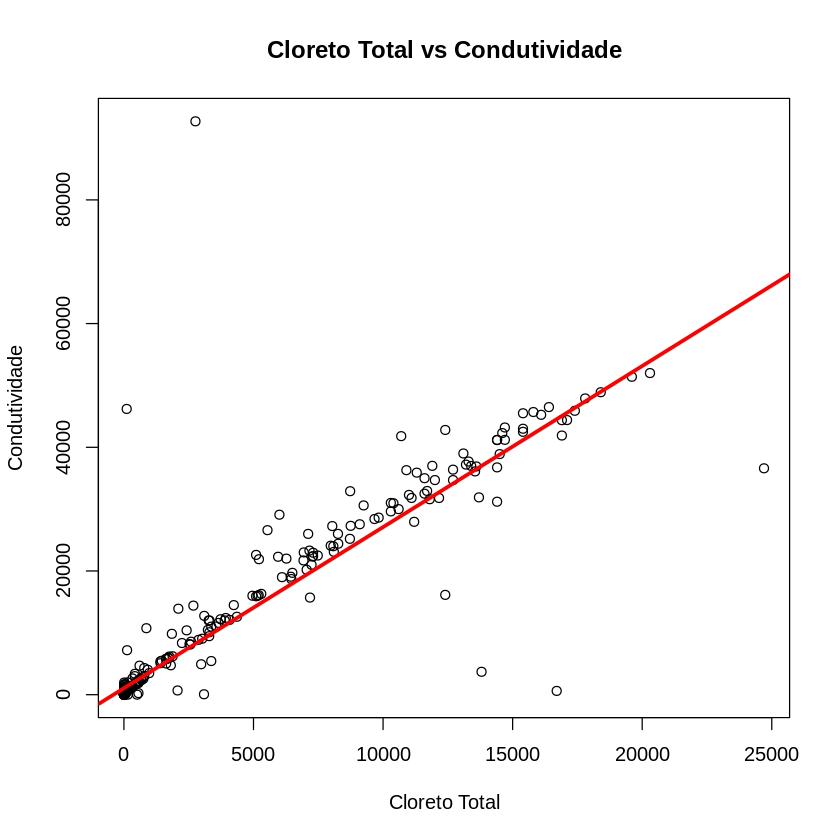

In [18]:
x <- Cloreto_Total
y <- Condutividade

plot(
  Cloreto_Total,
  Condutividade,
  xlab = "Cloreto Total",
  ylab = "Condutividade",
  main = "Cloreto Total vs Condutividade"
)

# Modelo de regressão linear
modelo_lm <- lm(Condutividade ~ Cloreto_Total, data = df)

# Linha de regressão
abline(modelo_lm,
       col = "red",
       lwd = 3)

summary(modelo_lm)

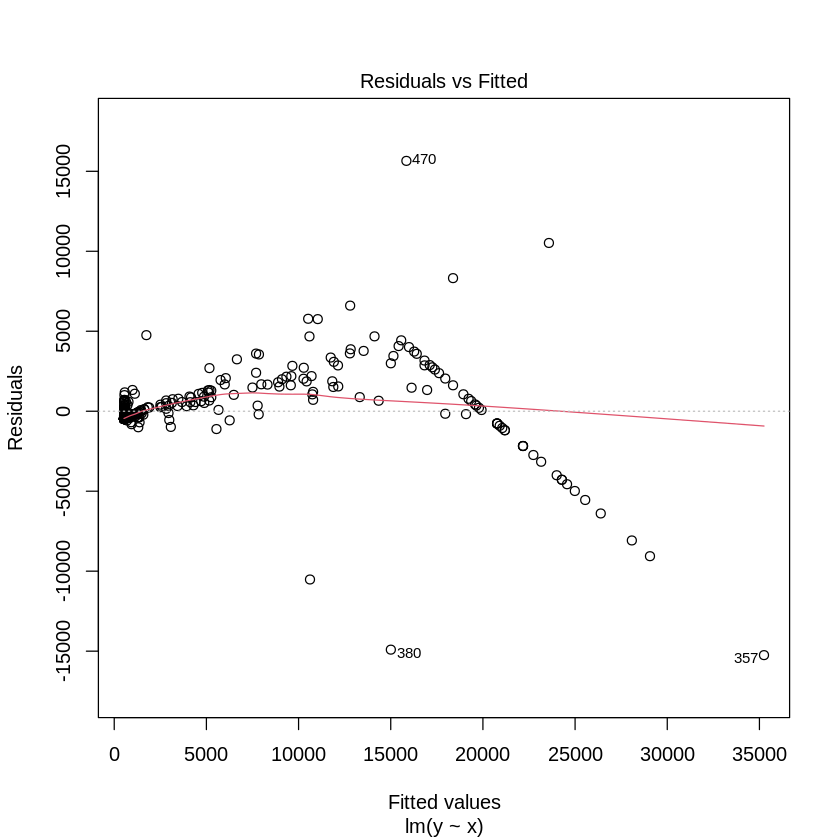

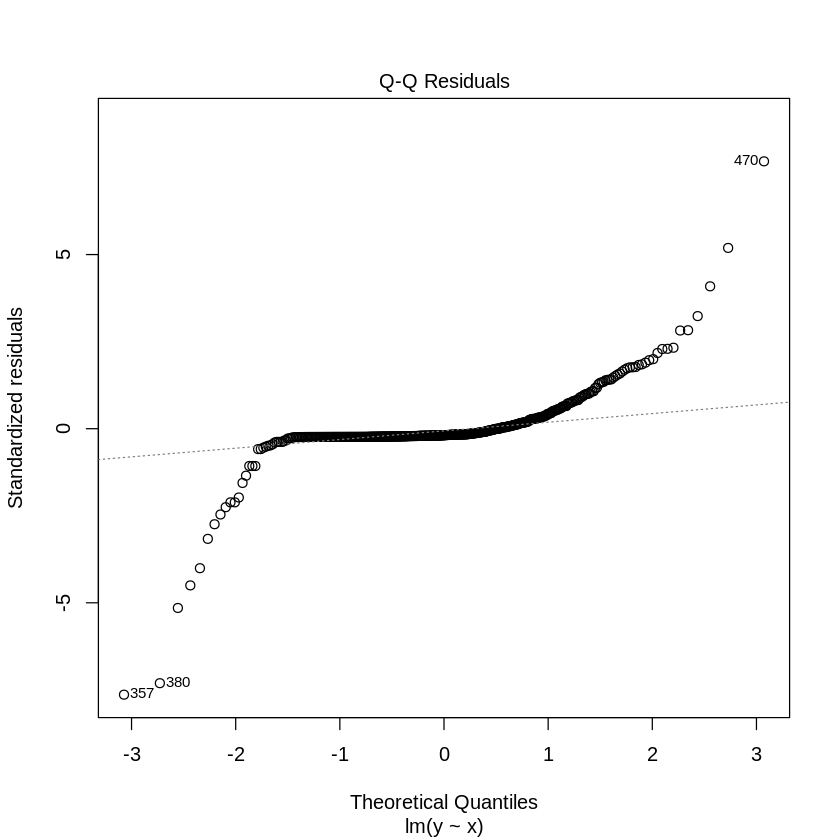

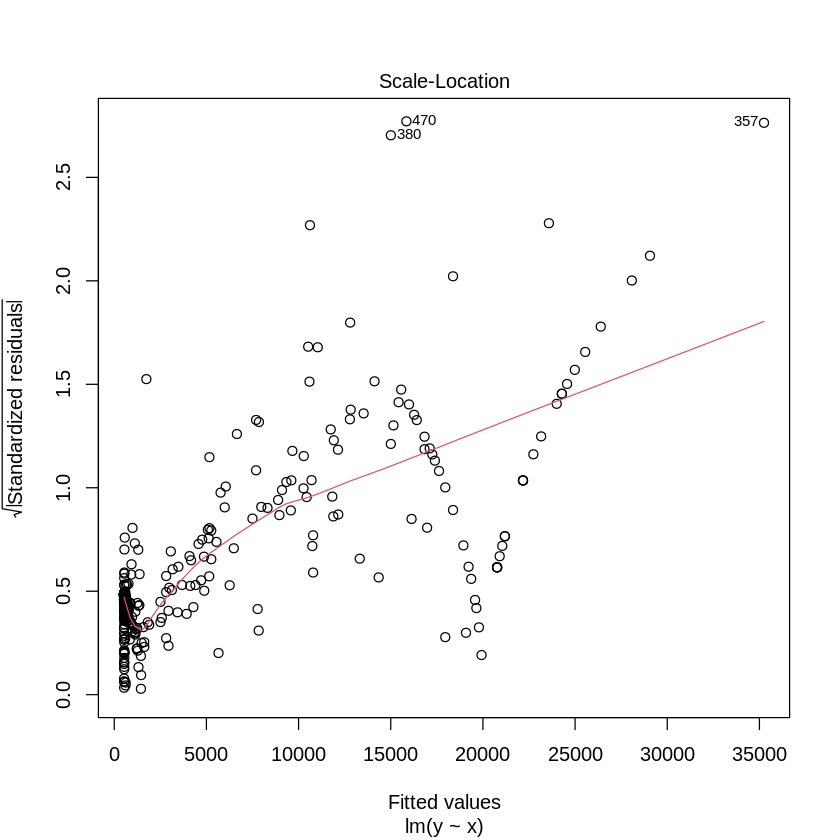


Call:
lm(formula = y ~ x, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-15248.0   -471.4   -382.6    213.6  15651.2 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 526.19233  106.51964    4.94 1.09e-06 ***
x             1.40574    0.02005   70.10  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2048 on 469 degrees of freedom
Multiple R-squared:  0.9129,	Adjusted R-squared:  0.9127 
F-statistic:  4913 on 1 and 469 DF,  p-value: < 2.2e-16


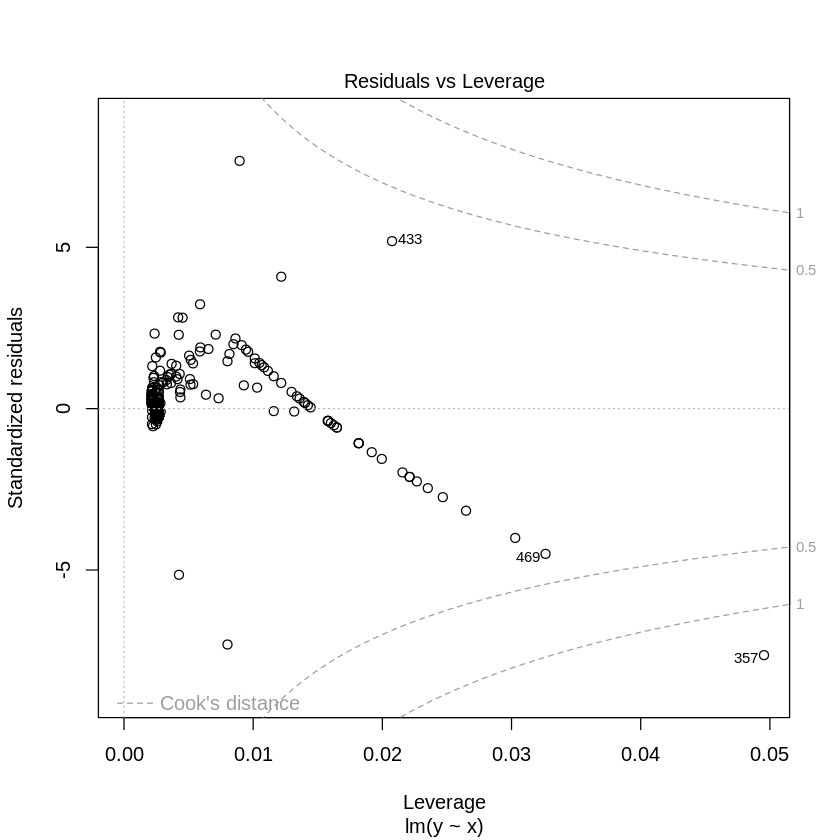

In [17]:
x <- df$Cloreto.Total
y <- df$Sólido.Dissolvido.Total

dados <- data.frame(x, y)

modelo <- lm(y ~ x, data = dados)

plot(modelo)
summary(modelo)

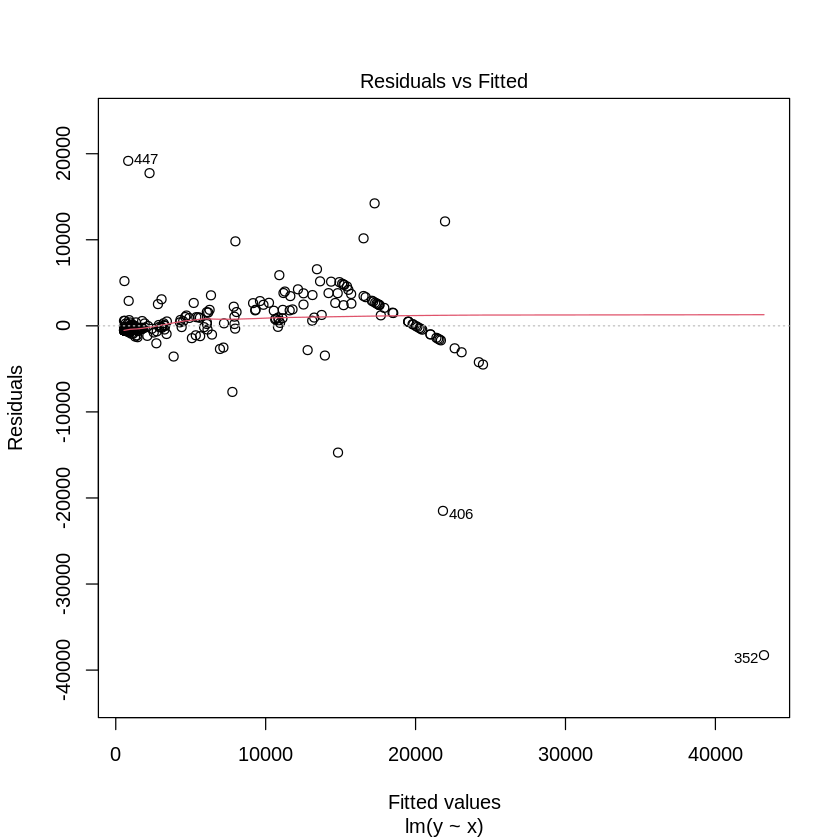

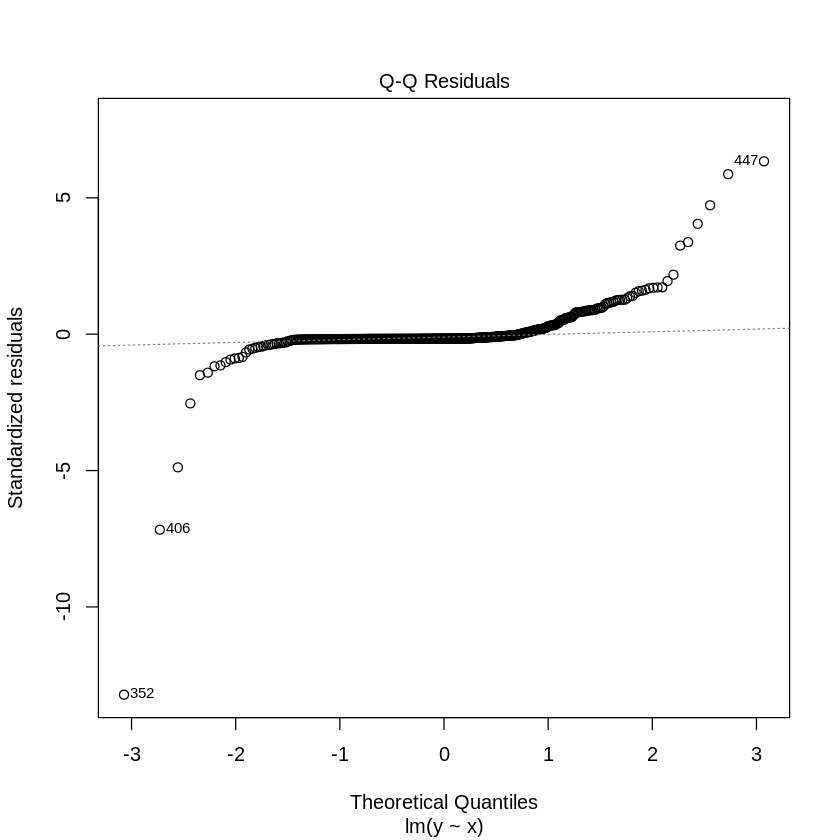

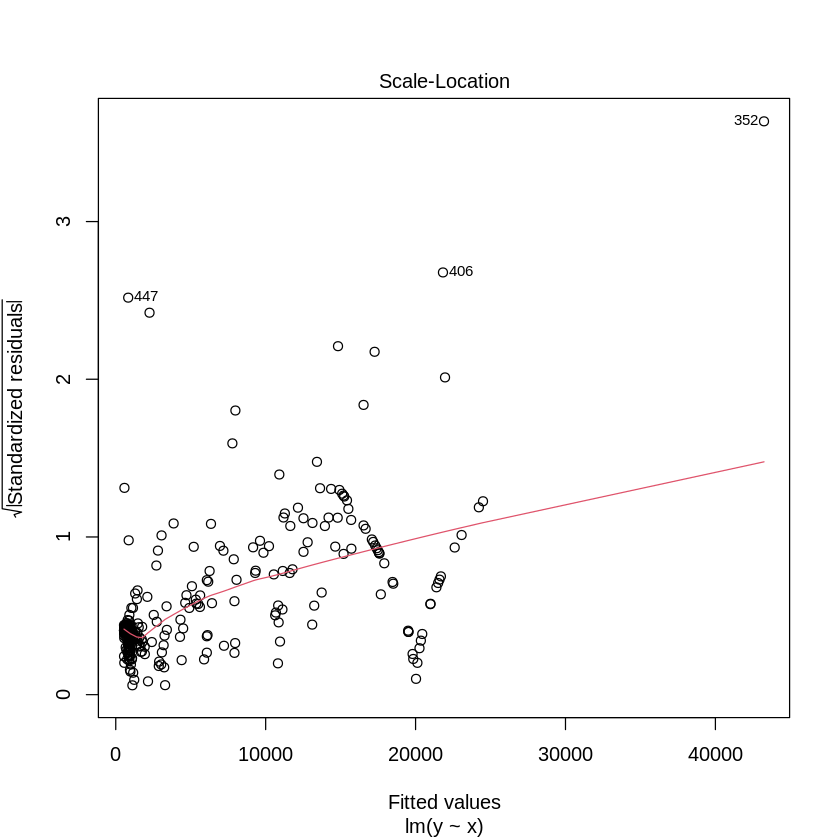


Call:
lm(formula = y ~ x, data = dados)

Residuals:
   Min     1Q Median     3Q    Max 
-38262   -521   -495   -123  19170 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 548.85017  159.47444   3.442  0.00063 ***
x             0.46055    0.01032  44.619  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3029 on 469 degrees of freedom
Multiple R-squared:  0.8093,	Adjusted R-squared:  0.8089 
F-statistic:  1991 on 1 and 469 DF,  p-value: < 2.2e-16


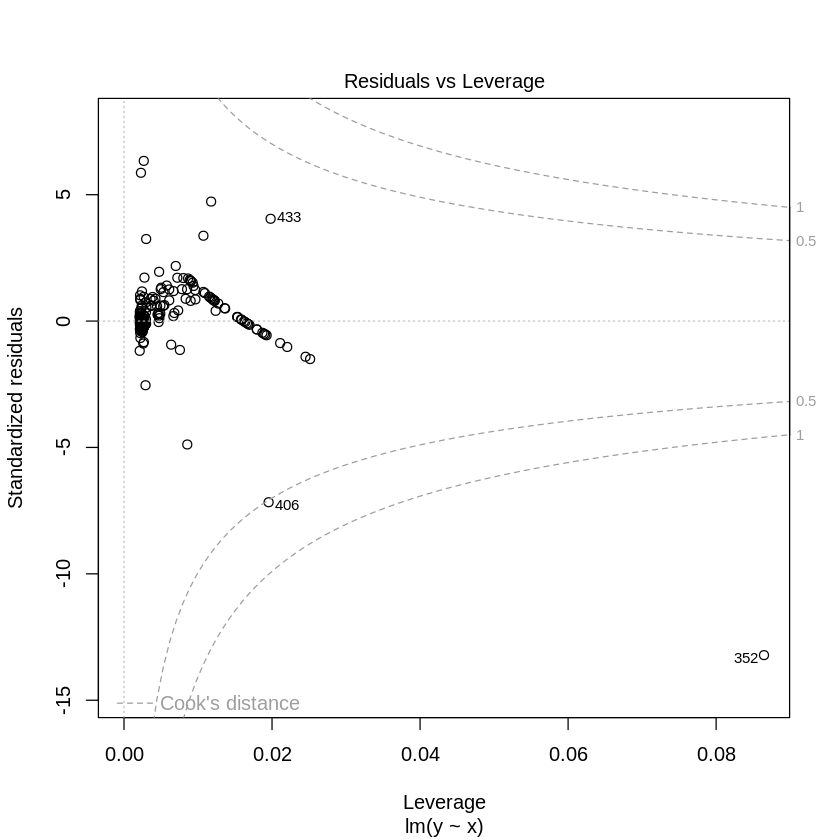

In [19]:
x <- df$Condutividade
y <- df$Sólido.Dissolvido.Total

dados <- data.frame(x, y)

modelo <- lm(y ~ x, data = dados)

plot(modelo)
summary(modelo)

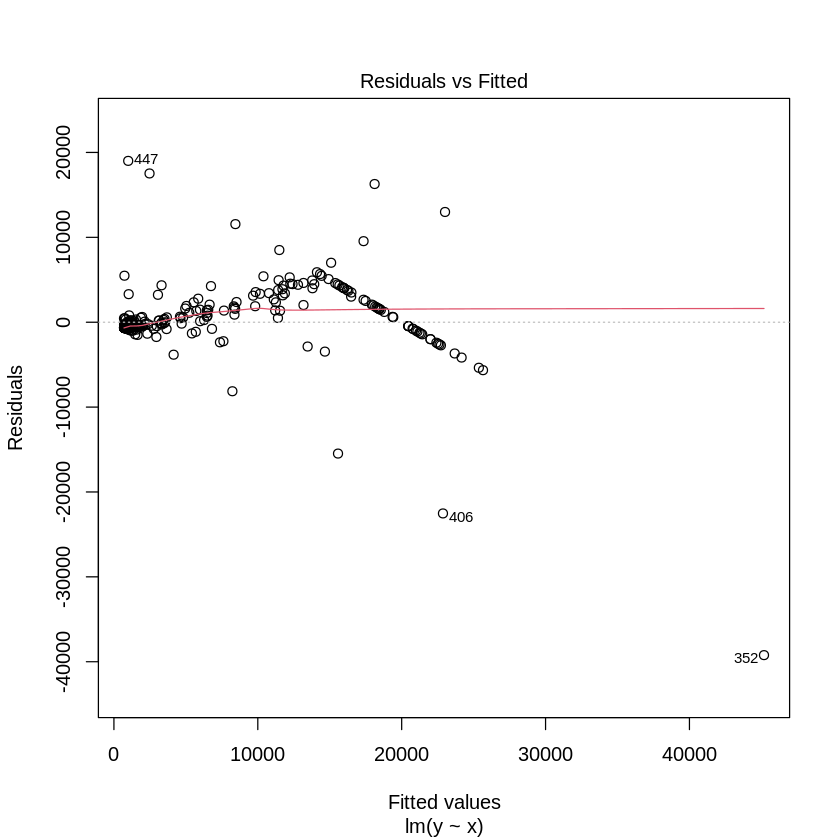

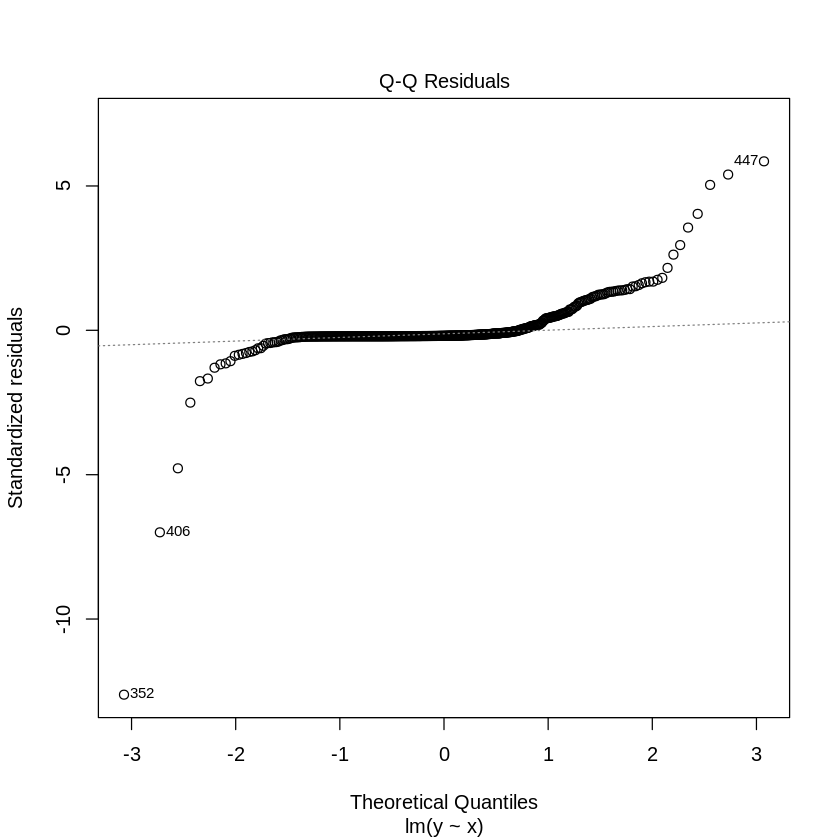

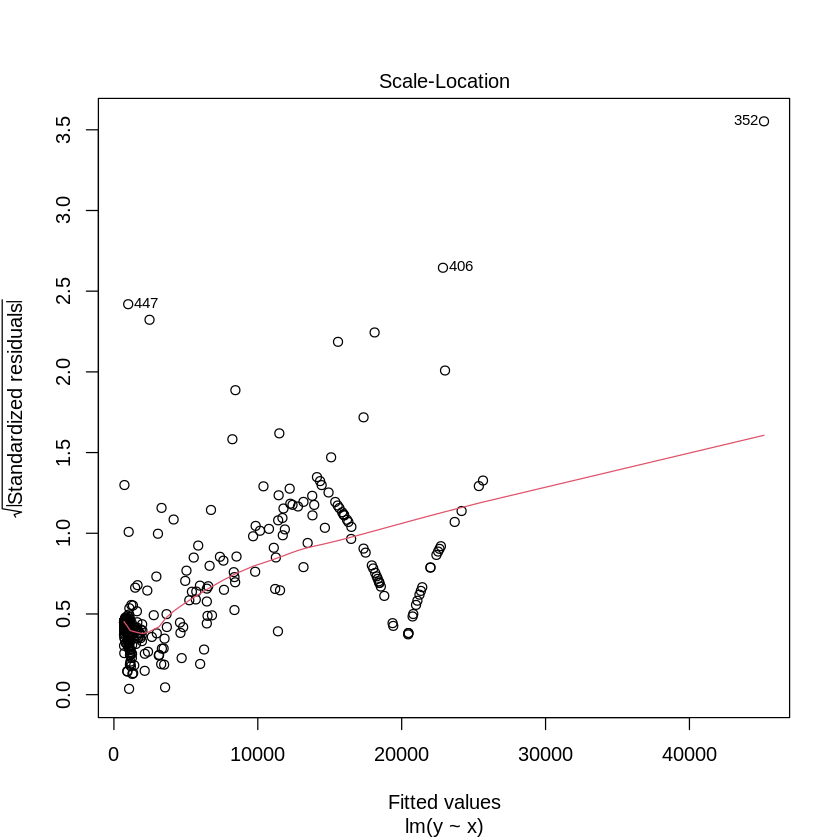


Call:
lm(formula = y ~ x, data = dados)

Residuals:
   Min     1Q Median     3Q    Max 
-39222   -668   -618   -118  19008 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 699.61286  171.20435   4.086 5.15e-05 ***
x             0.47985    0.01108  43.304  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3252 on 469 degrees of freedom
Multiple R-squared:  0.7999,	Adjusted R-squared:  0.7995 
F-statistic:  1875 on 1 and 469 DF,  p-value: < 2.2e-16


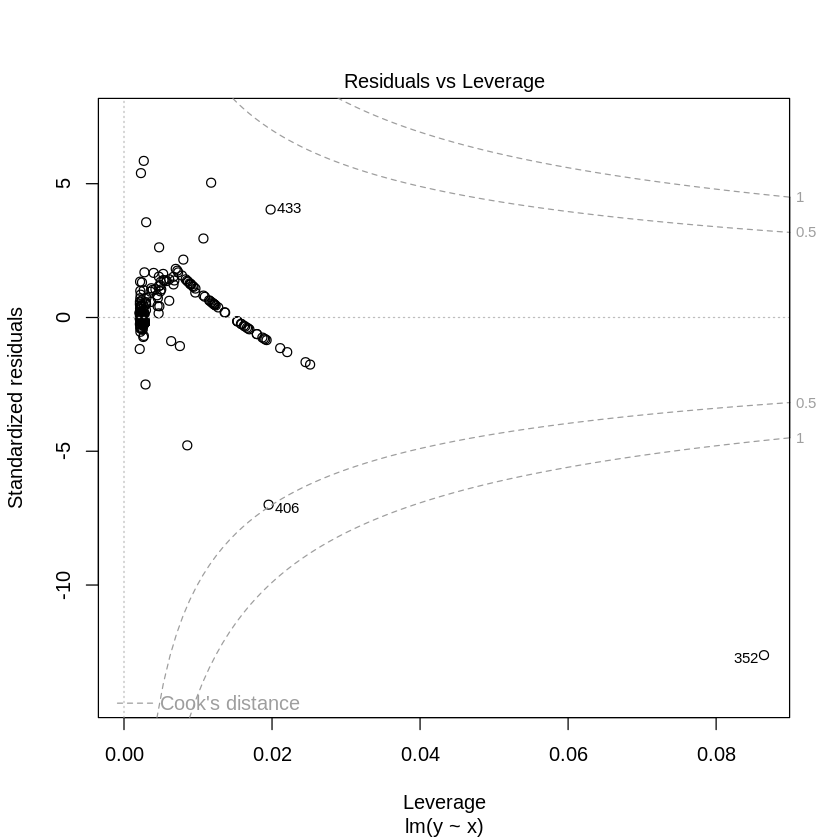

In [20]:
x <- df$Condutividade
y <- df$Sólido.Total

dados <- data.frame(x, y)

modelo <- lm(y ~ x, data = dados)

plot(modelo)
summary(modelo)

### KMeans

In [21]:
df_knn <- df[c("Sólido.Dissolvido.Total", "Sólido.Total", "Cloreto.Total", "Condutividade")]
df_knn <- na.omit(df_knn)

features <- c("Sólido.Dissolvido.Total", "Cloreto.Total")
features2 <- c("Sólido.Total", "Condutividade")
features3 <- c("Sólido.Dissolvido.Total", "Condutividade")

df_train <- df[, features]
df_train2 <- df[, features2]
df_train3 <- df[, features3]

df_train <- na.omit(df_train)
df_train2 <- na.omit(df_train2)
df_train3 <- na.omit(df_train3)

df_scale <- scale(df_train)
df_scale2 <- scale(df_train2)
df_scale3 <- scale(df_train3)

n_clusters <- 20
wcss <- numeric(n_clusters)
wcss2 <- numeric(n_clusters)
wcss3 <- numeric(n_clusters)

# finding the best k
for (k in 1:n_clusters){
  km_it <- kmeans(df_scale, centers = k, nstart = 25, iter.max = 100)
  wcss[k] <- km_it$tot.withinss
}

for (k in 1:n_clusters){
  km_it2 <- kmeans(df_scale2, centers = k, nstart = 25, iter.max = 100)
  wcss2[k] <- km_it2$tot.withinss
}

for (k in 1:n_clusters){
  km_it3 <- kmeans(df_scale3, centers = k, nstart = 25, iter.max = 100)
  wcss3[k] <- km_it3$tot.withinss
}



### Plot do KMeans


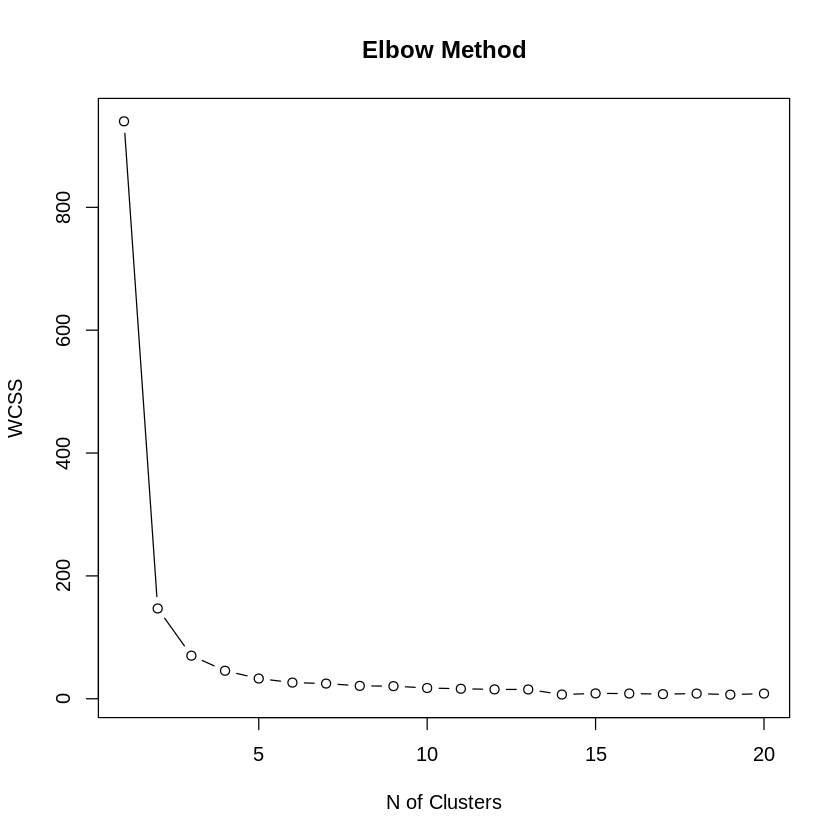

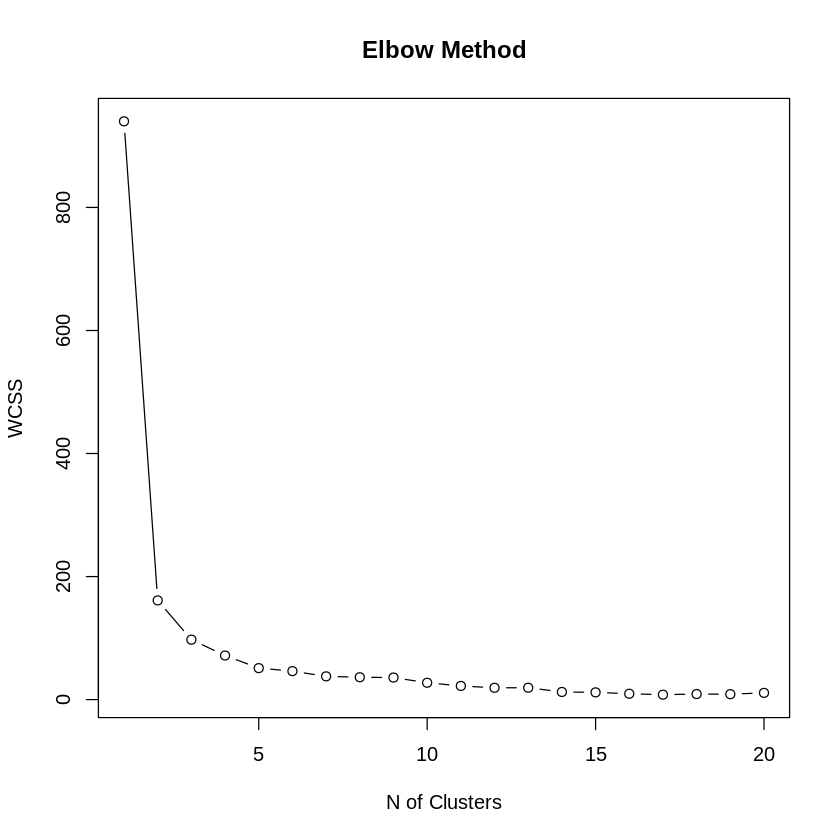

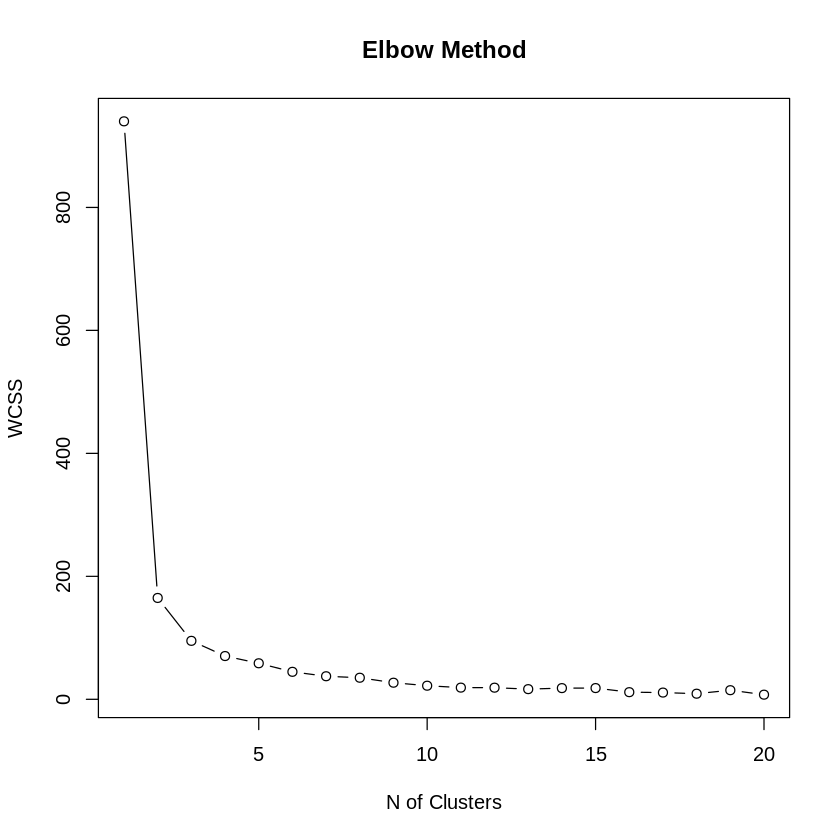

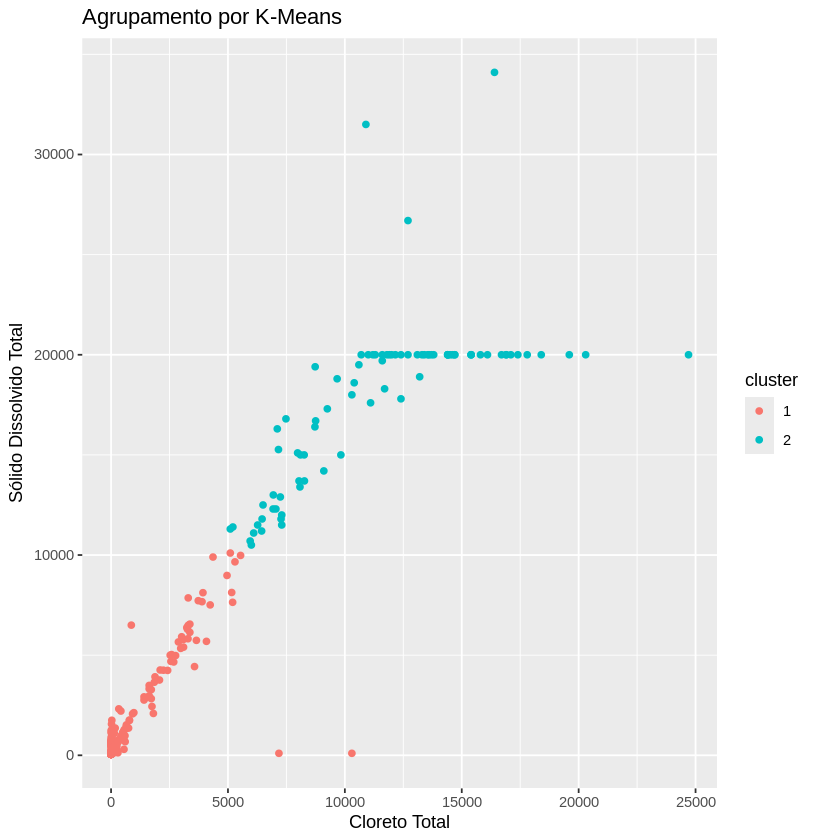

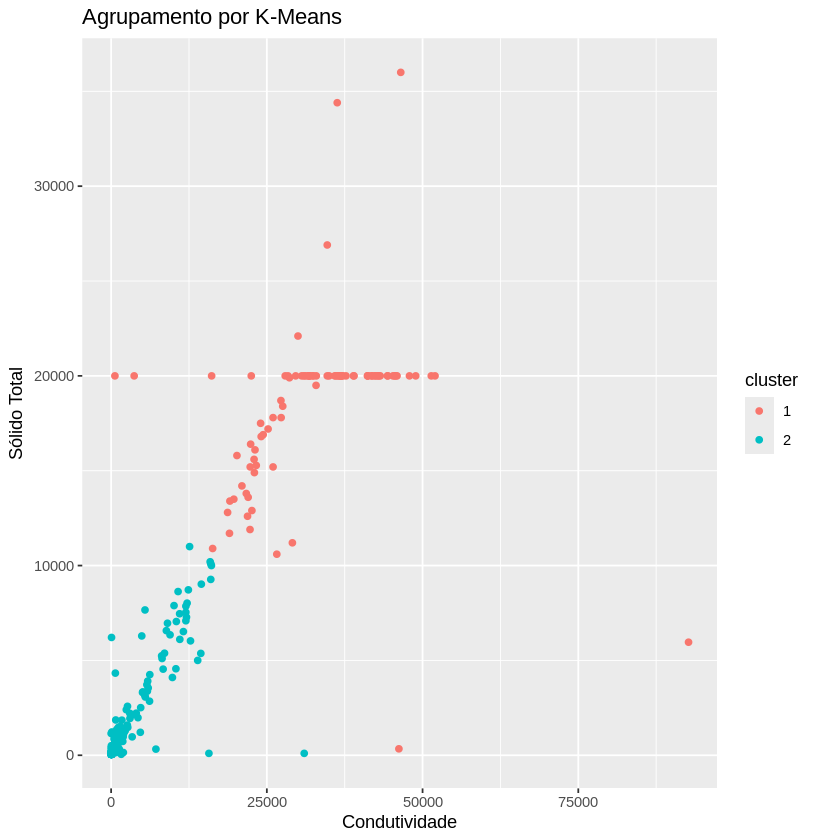

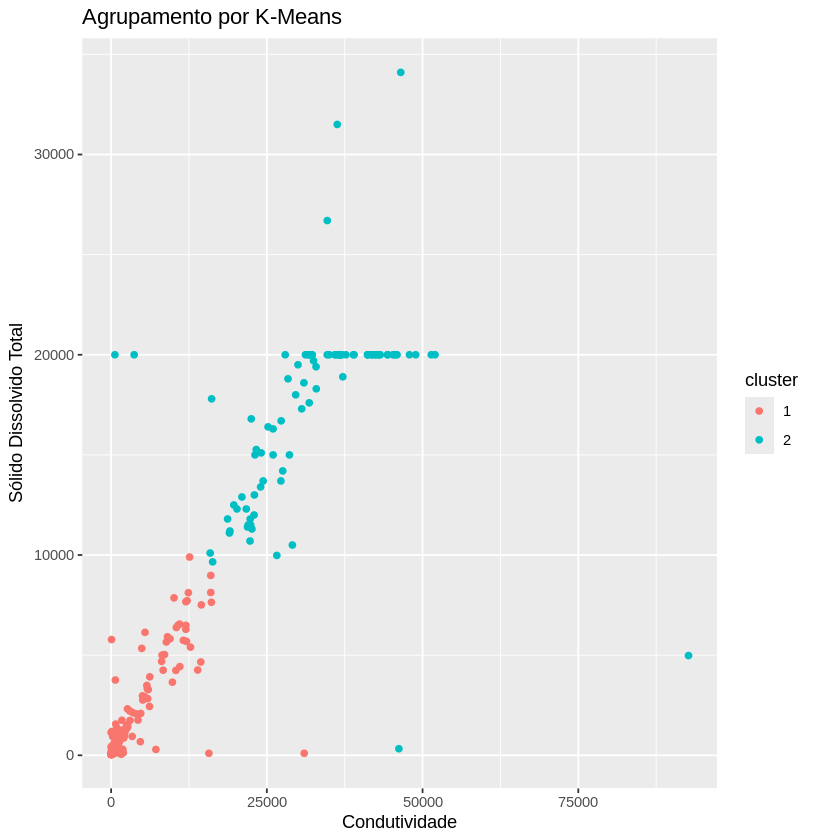

In [22]:
# visualizing WCSS
plot(
  1:n_clusters,
  wcss,
  type = "b",
  xlab = "N of Clusters",
  ylab = "WCSS",
  main = "Elbow Method"
)

plot(
  1:n_clusters,
  wcss2,
  type = "b",
  xlab = "N of Clusters",
  ylab = "WCSS",
  main = "Elbow Method"
)

plot(
  1:n_clusters,
  wcss3,
  type = "b",
  xlab = "N of Clusters",
  ylab = "WCSS",
  main = "Elbow Method"
)

kmeans_model <- kmeans(df_scale, center = 2, nstart = 25)
kmeans_model2 <- kmeans(df_scale2, center = 2, nstart = 25)
kmeans_model3 <- kmeans(df_scale3, center = 2, nstart = 25)

df_train$cluster <- as.factor(kmeans_model$cluster)
df_train2$cluster <- as.factor(kmeans_model2$cluster)
df_train3$cluster <- as.factor(kmeans_model3$cluster)

ggplot(df_train, aes(
  x = Cloreto.Total,
  y = Sólido.Dissolvido.Total,
  color = cluster
)) +
  geom_point() +
  labs(
    title = "Agrupamento por K-Means",
    x = "Cloreto Total",
    y = "Sólido Dissolvido Total"
  )


#png("Km Condutividade x Solido Total.png", width = 600, height = 450)
  ggplot(df_train2, aes(
  x = Condutividade,
  y = Sólido.Total,
  color = cluster
)) +
  geom_point() +
  labs(
    title = "Agrupamento por K-Means",
    x = "Condutividade",
    y = "Sólido Total"
  )
#dev.off()

#png("Km Condutividade x Solido Dissolvido.png", width = 600, height = 450)
  ggplot(df_train3, aes(
  x = Condutividade,
  y = Sólido.Dissolvido.Total,
  color = cluster
)) +
  geom_point() +
  labs(
    title = "Agrupamento por K-Means",
    x = "Condutividade",
    y = "Sólido Dissolvido Total"
  )
#dev.off()

### KNN

In [23]:

# Criando classe artificial
df$Classe <- ifelse(df$Cloreto.Total > 100,
                    "Alta",
                    "Baixa")

features <- c("Sólido.Dissolvido.Total",
              "Cloreto.Total")

df_knn <- df[, c(features, "Classe")]

df_knn <- na.omit(df_knn)

# Padronização
df_knn[, features] <- scale(df_knn[, features])

set.seed(123)

# Separação treino/teste
indices <- sample(1:nrow(df_knn),
                  0.7 * nrow(df_knn))

train <- df_knn[indices, ]
test <- df_knn[-indices, ]

# Modelo KNN
pred <- knn(
  train = train[, features],
  test = test[, features],
  cl = train$Classe,
  k = 5
)

# Matriz de confusão
table(Predito = pred,
      Real = test$Classe)

table(Predito = pred, Real = test$Classe)

       Real
Predito Alta Baixa
  Alta    54     2
  Baixa    0    86

       Real
Predito Alta Baixa
  Alta    54     2
  Baixa    0    86

### Random Forest


Call:
 randomForest(formula = Cloreto_Total ~ Condutividade + Solido_Dissolvido_Total +      Solido_Total + Ph + Turbidez + Escherichia_coli + Oxigenio_dissolvido +      Temperatura_da_agua, dados = df_num, ntree = 500, mtry = 2,      importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 500
No. of variables tried at each split: 2

          Mean of squared residuals: 1101253
                    % Var explained: 95.02


,%IncMSE,IncNodePurity
Condutividade,24.137327,2826209123
Solido_Dissolvido_Total,22.538991,3138493108
Solido_Total,24.305906,3314762184
Ph,7.624079,211273512
Turbidez,5.083100,110035740
Escherichia_coli,7.849098,184364705
Oxigenio_dissolvido,11.688483,421700655
Temperatura_da_agua,1.230467,88337881


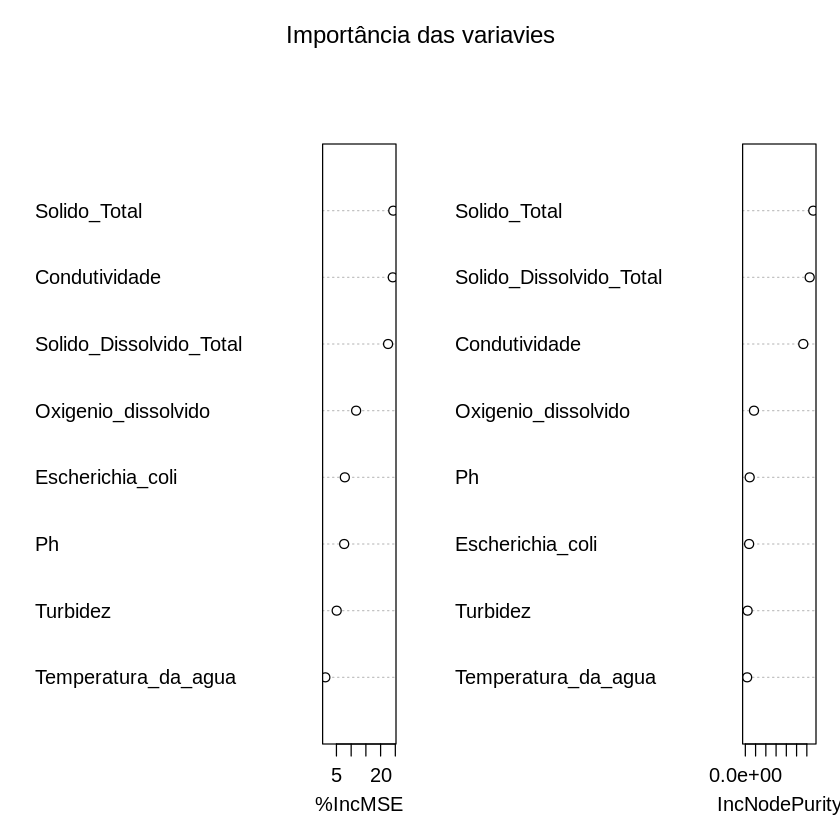

In [24]:
df_num <- df[sapply(df, is.numeric)]
df_num <- na.omit(df_num)

#Testando Random Forest com a variavel Cloreto total

set.seed(123)
modelo_rf <- randomForest(
    Cloreto_Total ~ Condutividade + Solido_Dissolvido_Total + Solido_Total + Ph + Turbidez + Escherichia_coli + Oxigenio_dissolvido + Temperatura_da_agua,
    dados = df_num,
    ntree = 500,
    mtry = 2,
    importance = TRUE
)

print(modelo_rf)

importance(modelo_rf)

#Grafico horrivel!!!
varImpPlot(modelo_rf, main = "Importância das variavies")

### DBSCAN

In [31]:
feature <- c("Sólido.Dissolvido.Total", "Cloreto.Total")
feature2 <- c("Condutividade", "Sólido.Dissolvido.Total")
feature3 <- c("Condutividade", "Sólido.Total")

df_scan <- df[, feature]
df_scan <- na.omit(df_scan)
df_scale <- scale(df_scan)

df_scan2 <- df[, feature2]
df_scan2 <- na.omit(df_scan2)
df_scale2 <- scale(df_scan2)

df_scan3 <- df[, feature3]
df_scan3 <- na.omit(df_scan3)
df_scale3 <- scale(df_scan3)

#Executando DBSCAN
modelo <- dbscan(df_scale, eps = 0.2, minPts = 5)
modelo2 <- dbscan(df_scale2, eps = 0.2, minPts = 5)
modelo3 <- dbscan(df_scale3, eps = 0.1, minPts = 5)

#Criando uma coluna cluster
df_scan$cluster <- modelo$cluster
df_scan2$cluster <- modelo2$cluster
df_scan3$cluster <- modelo3$cluster

#Isolando o cluster 1
cluster_1 <- subset(df_scan, cluster == 1)
cluster_2 <- subset(df_scan2, cluster == 1)
cluster_3 <- subset(df_scan3, cluster == 1)

#Pegando todos os clusters menos o primeiro
outros_clusters <- subset(df_scan, cluster != 1)
outros_clusters_2 <- subset(df_scan2, cluster != 1)
outros_clusters_3 <- subset(df_scan3, cluster != 1)

# Regressão Linear
modelo_cluster_1 <- lm(
  Cloreto.Total ~ Sólido.Dissolvido.Total,
  data = cluster_1
)

modelo_cluster_2 <- lm(
  Condutividade ~ Sólido.Dissolvido.Total,
  data = cluster_2
)

modelo_cluster_3 <- lm(
  Condutividade ~ Sólido.Total,
  data = cluster_3
)
summary(modelo_cluster_1)

#Regressão com outros Clusters
modelo_outros <- lm(
  Cloreto.Total ~ Sólido.Dissolvido.Total,
  data = outros_clusters
)

modelo_outros_2 <- lm(
  Condutividade ~ Sólido.Dissolvido.Total,
  data = outros_clusters_2
)

modelo_outros_3 <- lm(
  Condutividade ~ Sólido.Total,
  data = outros_clusters_3
)

summary(modelo_outros)


Call:
lm(formula = Cloreto.Total ~ Sólido.Dissolvido.Total, data = cluster_1)

Residuals:
    Min      1Q  Median      3Q     Max 
-827.40  -10.53   32.83   58.50 1283.72 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)             -81.733873  11.088493  -7.371 1.09e-12 ***
Sólido.Dissolvido.Total   0.534541   0.006274  85.199  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 190.9 on 375 degrees of freedom
Multiple R-squared:  0.9509,	Adjusted R-squared:  0.9507 
F-statistic:  7259 on 1 and 375 DF,  p-value: < 2.2e-16



Call:
lm(formula = Cloreto.Total ~ Sólido.Dissolvido.Total, data = outros_clusters)

Residuals:
    Min      1Q  Median      3Q     Max 
-8573.4 -1663.2  -903.4  1576.9 11876.9 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             1.258e+03  1.051e+03   1.197    0.234    
Sólido.Dissolvido.Total 5.783e-01  5.993e-02   9.649 1.25e-15 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3066 on 92 degrees of freedom
Multiple R-squared:  0.503,	Adjusted R-squared:  0.4976 
F-statistic: 93.11 on 1 and 92 DF,  p-value: 1.248e-15


###Plot DBSCAN

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


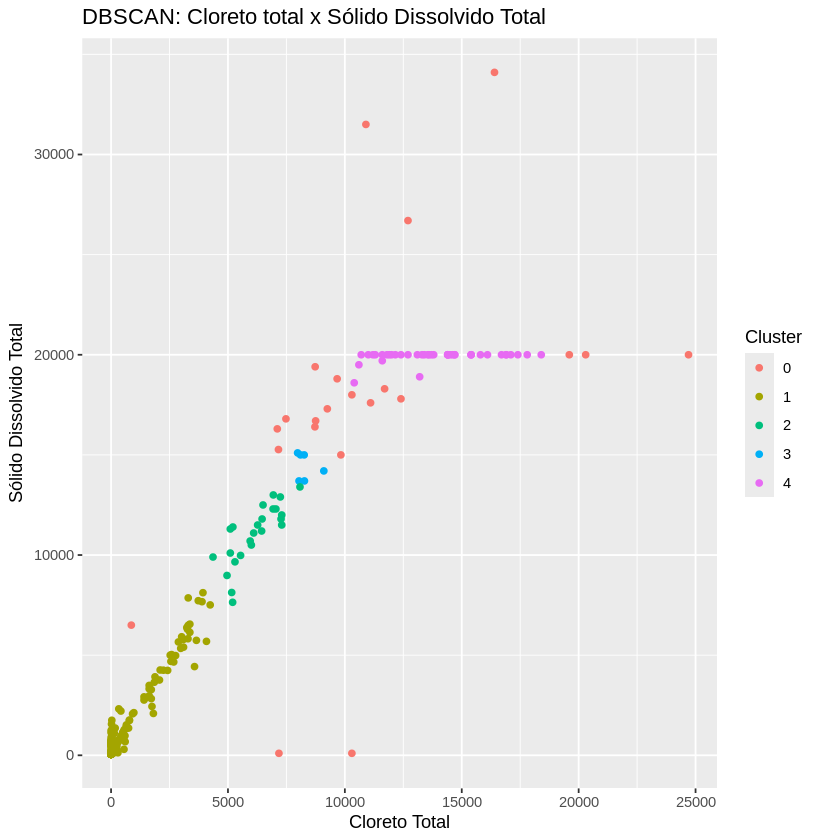

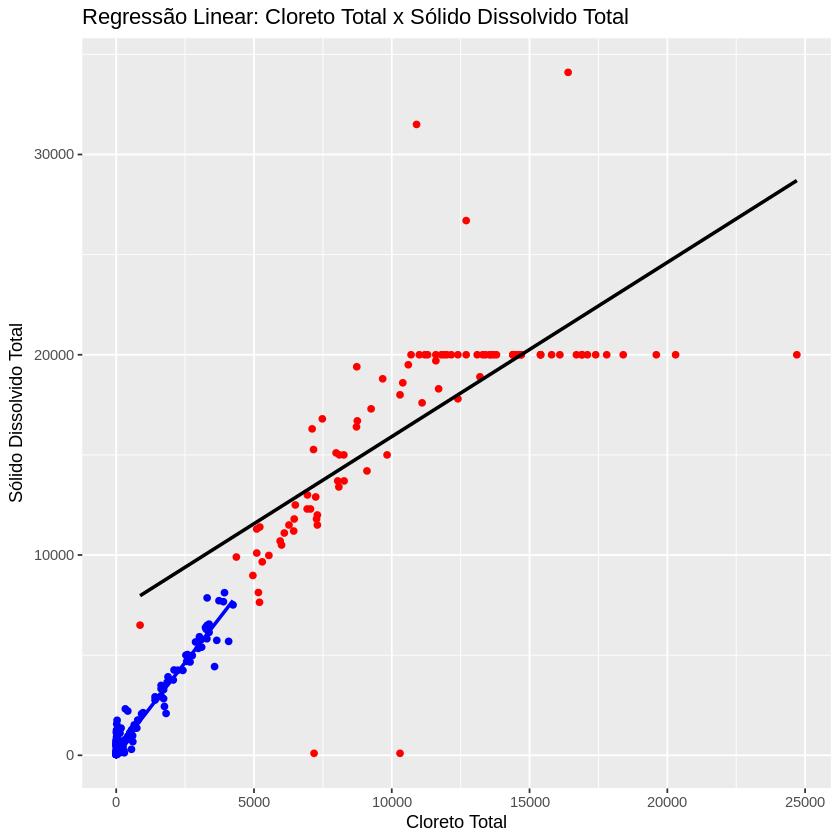

In [28]:
ggplot(df_scan, aes(
  x = Cloreto.Total,
  y = Sólido.Dissolvido.Total,
  color = as.factor(cluster)
)) +
  geom_point() +
  labs(
    title = "DBSCAN: Cloreto total x Sólido Dissolvido Total",
    x = "Cloreto Total",
    y = "Sólido Dissolvido Total",
    color = "Cluster"
  )
  ggplot() +
  geom_point(data = cluster_1,
             aes(x = Cloreto.Total,
                 y = Sólido.Dissolvido.Total),
             color = "blue") +
  geom_smooth(data = cluster_1,
              aes(x = Cloreto.Total,
                  y = Sólido.Dissolvido.Total),
              method = "lm",
              se = FALSE,
              color = "blue") +
  geom_point(data = outros_clusters,
             aes(x = Cloreto.Total,
                 y = Sólido.Dissolvido.Total),
             color = "red") +
  geom_smooth(data = outros_clusters,
              aes(x = Cloreto.Total,
                  y = Sólido.Dissolvido.Total),
              method = "lm",
              se = FALSE,
              color = "black") +
  labs(
    title = "Regressão Linear: Cloreto Total x Sólido Dissolvido Total",
    x = "Cloreto Total",
    y = "Sólido Dissolvido Total"
  )


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


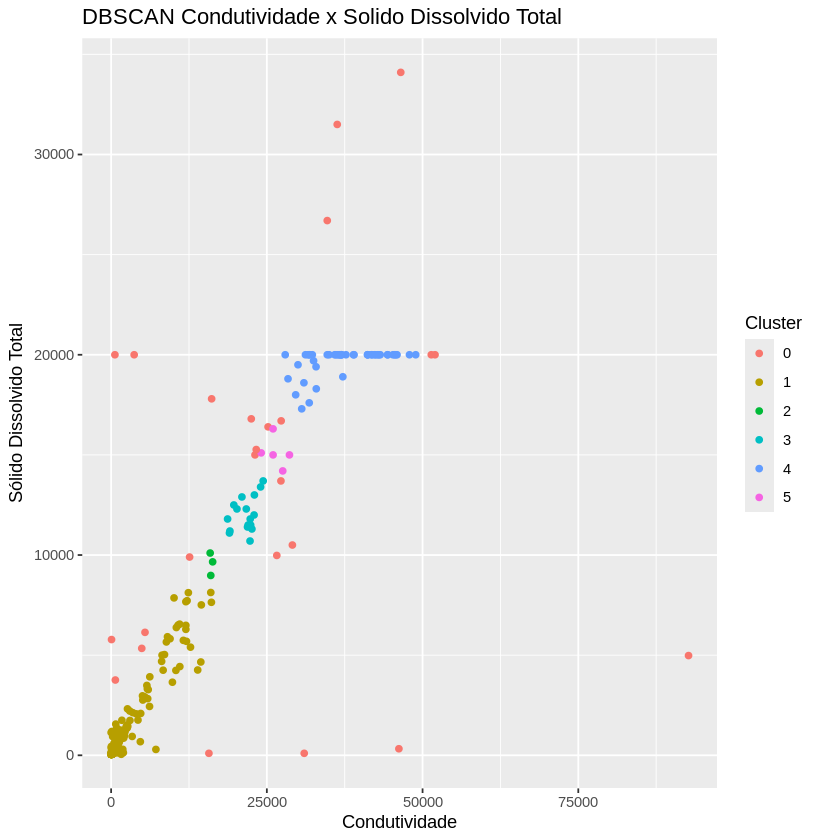

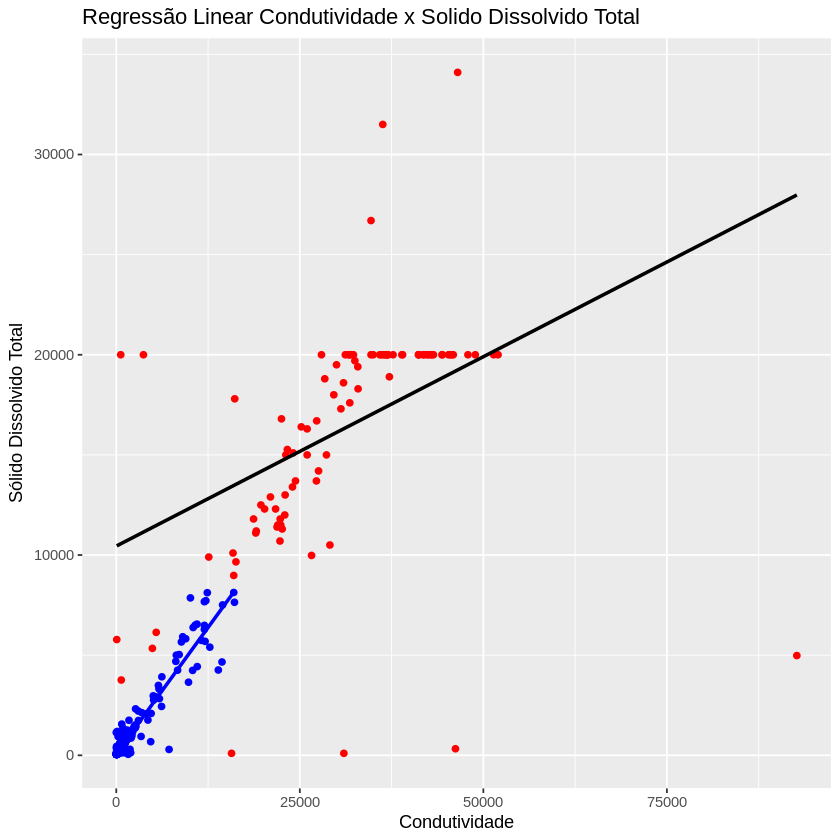

In [29]:
ggplot(df_scan2, aes(
  x = Condutividade,
  y = Sólido.Dissolvido.Total,
  color = as.factor(cluster)
)) +
  geom_point() +
  labs(
    title = "DBSCAN Condutividade x Solido Dissolvido Total",
    x = "Condutividade",
    y = "Sólido Dissolvido Total",
    color = "Cluster"
  )

ggplot() +
  geom_point(data = cluster_2,
             aes(x = Condutividade,
                 y = Sólido.Dissolvido.Total),
             color = "blue") +
  geom_smooth(data = cluster_2,
              aes(x = Condutividade,
                  y = Sólido.Dissolvido.Total),
              method = "lm",
              se = FALSE,
              color = "blue") +
  geom_point(data = outros_clusters_2,
             aes(x = Condutividade,
                 y = Sólido.Dissolvido.Total),
             color = "red") +
  geom_smooth(data = outros_clusters_2,
              aes(x = Condutividade,
                  y = Sólido.Dissolvido.Total),
              method = "lm",
              se = FALSE,
              color = "black") +
  labs(
    title = "Regressão Linear Condutividade x Solido Dissolvido Total",
    x = "Condutividade",
    y = "Sólido Dissolvido Total"
  )


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


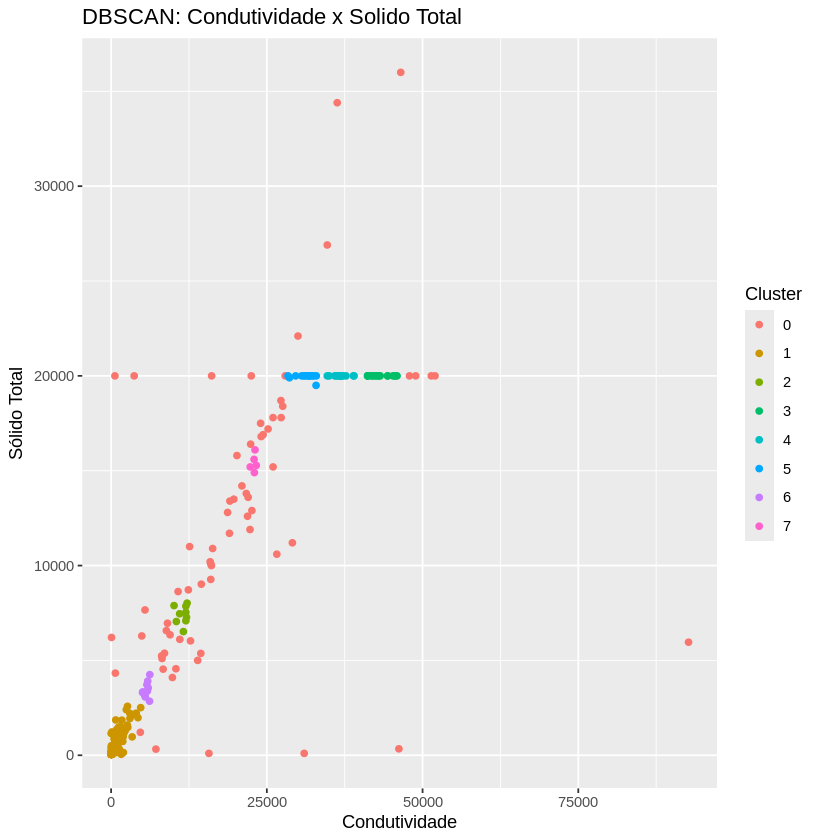

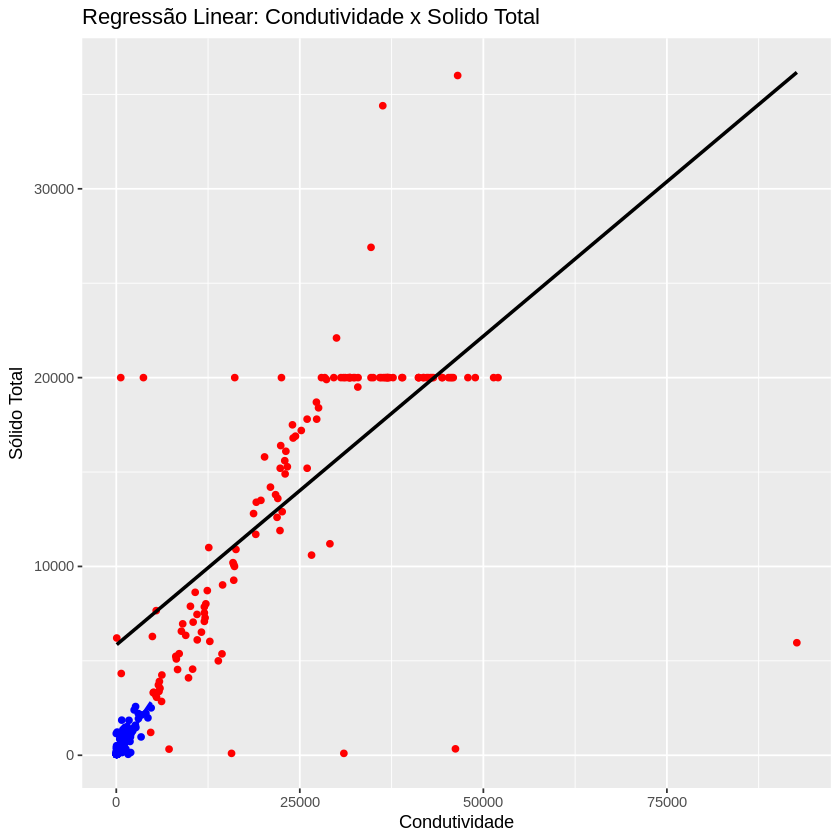

In [32]:
ggplot(df_scan3, aes(
  x = Condutividade,
  y = Sólido.Total,
  color = as.factor(cluster)
)) +
  geom_point() +
  labs(
    title = "DBSCAN: Condutividade x Solido Total",
    x = "Condutividade",
    y = "Sólido Total",
    color = "Cluster"
  )

  ggplot() +
  geom_point(data = cluster_3,
             aes(x = Condutividade,
                 y = Sólido.Total),
             color = "blue") +
  geom_smooth(data = cluster_3,
              aes(x = Condutividade,
                  y = Sólido.Total),
              method = "lm",
              se = FALSE,
              color = "blue") +
  geom_point(data = outros_clusters_3,
             aes(x = Condutividade,
                 y = Sólido.Total),
             color = "red") +
  geom_smooth(data = outros_clusters_3,
              aes(x = Condutividade,
                  y = Sólido.Total),
              method = "lm",
              se = FALSE,
              color = "black") +
  labs(
    title = "Regressão Linear: Condutividade x Solido Total",
    x = "Condutividade",
    y = "Sólido Total"
  )